In [1]:
# =============================================================================
# CELL 0: IMPORTS & CONFIGURATION
# =============================================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, TimeSeriesSplit, RandomizedSearchCV
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, matthews_corrcoef,
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.utils import resample
from scipy.optimize import differential_evolution
from scipy.stats import randint, uniform
from scipy import stats
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import time

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "DejaVu Sans"

OUT_DIR  = r"/kaggle/working/output"
os.makedirs(OUT_DIR, exist_ok=True)

WINDOW_SIZE       = 6
N_FOLDS           = 10
N_TOP_PRODUCTS    = 9
N_CLUSTERS_PAPER  = 3
REVENUE_THRESHOLD = 0.80
RANDOM_STATE      = 42

print("=" * 70)
print("COMPARISON STUDY: Thammaboosadee (2018) vs Improved Approach")
print("UCI Online Retail II Dataset")
print("=" * 70)

# ── Reproducibility helper ────────────────────────────────────────────────
import random as _random_module

def set_global_seed(seed=42):
    """Set seed for numpy, random, os.environ for reproducibility."""
    _random_module.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_global_seed(RANDOM_STATE)
print("set_global_seed defined.")


COMPARISON STUDY: Thammaboosadee (2018) vs Improved Approach
UCI Online Retail II Dataset
set_global_seed defined.


In [2]:
# =============================================================================
# CELL 1: LOAD & CLEAN DATA  (shared)
# =============================================================================

print("\n" + "=" * 70)
print("CELL 1: LOAD & CLEAN DATA")
print("=" * 70)

import pandas as pd

# ── Load dataset: Kaggle native path hoặc kagglehub fallback ─────────────
_KAGGLE_CSV = "/kaggle/input/online-retail-ii-uci/online_retail_II.csv"
_KAGGLE_XLS = "/kaggle/input/online-retail-ii-uci/online_retail_II.xlsx"

if os.path.exists(_KAGGLE_CSV):
    df = pd.read_csv(_KAGGLE_CSV, encoding="utf-8", low_memory=False)
    print(f"Loaded from Kaggle input (CSV): {df.shape}")
elif os.path.exists(_KAGGLE_XLS):
    df = pd.read_excel(_KAGGLE_XLS)
    print(f"Loaded from Kaggle input (XLSX): {df.shape}")
else:
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            "mashlyn/online-retail-ii-uci",
            "online_retail_II.csv",
        )
        print(f"Loaded via kagglehub: {df.shape}")
    except Exception as _e:
        raise FileNotFoundError(
            f"Dataset không tìm thấy ({_e}). "
            "Thêm dataset 'mashlyn/online-retail-ii-uci' vào notebook "
            "qua menu Add Data trên Kaggle."
        )

print(f"Raw shape: {df.shape}")

df = df.dropna(subset=["Customer ID"])
df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]
df = df.drop_duplicates()
df = df[df["StockCode"].astype(str).str.match(r"^\d{5}")]

df["TotalPrice"]  = df["Quantity"] * df["Price"]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["YearMonth"]   = df["InvoiceDate"].dt.to_period("M")

print(f"Cleaned shape : {df.shape}")
print(f"Date range    : {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Customers     : {df['Customer ID'].nunique():,}")
print(f"Stock codes   : {df['StockCode'].nunique():,}")

european_countries = [
    'France','Germany','Spain','Italy','Netherlands','Belgium',
    'Switzerland','Portugal','Austria','Denmark','Norway','Sweden',
    'Finland','Ireland','Iceland','Poland','Greece','Czech Republic',
    'Lithuania','Malta','Cyprus','Channel Islands','EIRE'
]

def map_region(country):
    if pd.isna(country):          return "Local"
    c = str(country).strip()
    if c == "United Kingdom":     return "Local"
    elif c in european_countries: return "Europe"
    else:                         return "Asian"

df["Region"] = df["Country"].apply(map_region)

all_periods = pd.period_range(
    df["InvoiceDate"].min(),
    df["InvoiceDate"].max(), freq="M"
).astype(str).tolist()

total_revenue_all = df["TotalPrice"].sum()

print(f"\nRegion distribution:")
print(df["Region"].value_counts().to_string())
print(f"\nTotal monthly periods: {len(all_periods)}")



CELL 1: LOAD & CLEAN DATA
Loaded via kagglehub: (1067371, 8)
Raw shape: (1067371, 8)
Cleaned shape : (776577, 10)
Date range    : 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Customers     : 5,852
Stock codes   : 4,619

Region distribution:
Region
Local     699608
Europe     71940
Asian       5029

Total monthly periods: 25


In [3]:
# =============================================================================
# CELL 2: PRODUCT SELECTION
#   2A — Paper : Top-9 by transaction count
#   2B — New   : Pareto 80% revenue + behavioral clustering
# =============================================================================

print("\n" + "=" * 70)
print("CELL 2A: PAPER — Top-9 Products (fixed)")
print("=" * 70)

paper_products = (
    df.groupby("StockCode")["Invoice"].nunique()
    .nlargest(N_TOP_PRODUCTS)
    .index.tolist()
)
paper_revenue = df[df["StockCode"].isin(paper_products)]["TotalPrice"].sum()

print(f"Selected top {N_TOP_PRODUCTS} products:")
for p in paper_products:
    desc  = df[df["StockCode"]==p]["Description"].mode()
    d_str = desc.iloc[0][:40] if len(desc) > 0 else "N/A"
    n_inv = df[df["StockCode"]==p]["Invoice"].nunique()
    rev   = df[df["StockCode"]==p]["TotalPrice"].sum()
    print(f"  {p}: {d_str:<40} ({n_inv:>4} invoices, £{rev:>10,.0f})")

print(f"\nRevenue covered: £{paper_revenue:,.0f} "
      f"({paper_revenue/total_revenue_all:.1%} of total)")

# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CELL 2B: NEW — Pareto 80% + Behavioral Clustering")
print("=" * 70)

product_revenue = (
    df.groupby("StockCode")
    .agg(
        Total_Revenue  =("TotalPrice",  "sum"),
        N_Customers    =("Customer ID", "nunique"),
        N_Transactions =("Invoice",     "nunique"),
        Avg_Price      =("Price",       "mean"),
        Avg_Quantity   =("Quantity",    "mean"),
    )
    .sort_values("Total_Revenue", ascending=False)
    .reset_index()
)
product_revenue["Revenue_Pct"]    = (product_revenue["Total_Revenue"]
                                     / product_revenue["Total_Revenue"].sum())
product_revenue["Revenue_Cumsum"] = product_revenue["Revenue_Pct"].cumsum()

pareto_products = product_revenue[
    product_revenue["Revenue_Cumsum"].shift(1, fill_value=0) < REVENUE_THRESHOLD
].copy()

n_pareto   = len(pareto_products)
pareto_rev = pareto_products["Total_Revenue"].sum()
print(f"Total products      : {df['StockCode'].nunique():,}")
print(f"Pareto 80% products : {n_pareto}")
print(f"Revenue covered     : £{pareto_rev:,.0f} "
      f"({pareto_rev/total_revenue_all:.1%})")

# Product behavioral clustering
group_features = pareto_products[
    ["Avg_Price","Avg_Quantity","N_Customers","N_Transactions"]
].copy()
group_scaler = StandardScaler()
group_scaled = group_scaler.fit_transform(np.log1p(group_features))

print("\n--- Product Group Silhouette Scores ---")
sil_prod  = []
k_range_prod = range(2, min(15, n_pareto//5 + 1))
for k in k_range_prod:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(group_scaled)
    s   = silhouette_score(group_scaled, lbl)
    sil_prod.append(s)
    print(f"  k={k:>2}: Silhouette={s:.4f}")

optimal_product_groups = list(k_range_prod)[np.argmax(sil_prod)]
print(f"\n=> Optimal product groups: {optimal_product_groups} "
      f"(Silhouette={max(sil_prod):.4f})")

km_prod = KMeans(n_clusters=optimal_product_groups,
                 random_state=RANDOM_STATE, n_init=10)
pareto_products["ProductGroup"] = km_prod.fit_predict(group_scaled)
pareto_stock_codes = pareto_products["StockCode"].tolist()
df_pareto          = df[df["StockCode"].isin(pareto_stock_codes)].copy()

print("\n--- Product Group Summary ---")
for g in range(optimal_product_groups):
    grp = pareto_products[pareto_products["ProductGroup"] == g]
    print(f"  Group {g}: {len(grp):>3} products  "
          f"Avg Price=£{grp['Avg_Price'].mean():>7.2f}  "
          f"Revenue=£{grp['Total_Revenue'].sum():>12,.0f}")



CELL 2A: PAPER — Top-9 Products (fixed)
Selected top 9 products:
  85123A: WHITE HANGING HEART T-LIGHT HOLDER       (4895 invoices, £   247,203)
  22423: REGENCY CAKESTAND 3 TIER                 (3317 invoices, £   277,656)
  85099B: JUMBO BAG RED RETROSPOT                  (3260 invoices, £   167,921)
  84879: ASSORTED COLOUR BIRD ORNAMENT            (2652 invoices, £   124,352)
  20725: LUNCH BAG RED RETROSPOT                  (2579 invoices, £    59,375)
  21212: PACK OF 72 RETROSPOT CAKE CASES          (2508 invoices, £    43,390)
  47566: PARTY BUNTING                            (2077 invoices, £   103,283)
  22383: LUNCH BAG SUKI  DESIGN                   (2004 invoices, £    38,008)
  20727: LUNCH BAG  BLACK SKULL.                  (1997 invoices, £    39,904)

Revenue covered: £1,101,092 (6.5% of total)

CELL 2B: NEW — Pareto 80% + Behavioral Clustering
Total products      : 4,619
Pareto 80% products : 1002
Revenue covered     : £13,655,570 (80.0%)

--- Product Group Silhouett


CELL 3: CUSTOMER SEGMENTATION

--- 3A: Paper approach (fixed k=3) ---
  Silhouette     : 0.3471
  Davies-Bouldin : 1.0371
  Calinski-Harab.: 5176.82

--- 3B: New approach (optimal k via Elbow + Silhouette) ---
  k= 2: SSE=   8561.59  Silhouette=0.4383
  k= 3: SSE=   6337.65  Silhouette=0.3471
  k= 4: SSE=   4907.53  Silhouette=0.3651
  k= 5: SSE=   4090.11  Silhouette=0.3425
  k= 6: SSE=   3549.37  Silhouette=0.3351
  k= 7: SSE=   3182.08  Silhouette=0.3028
  k= 8: SSE=   2892.13  Silhouette=0.2953
  k= 9: SSE=   2650.23  Silhouette=0.2894
  k=10: SSE=   2460.21  Silhouette=0.2887

=> Optimal k = 3
  Silhouette     : 0.3471
  Davies-Bouldin : 1.0371
  Calinski-Harab.: 5176.82

Segment distribution (k=3):
Segment
Good        1221
Moderate    2262
Normal      2369

--- Clustering Quality: Paper (k=3) vs New (k=optimal) ---
             k  Silhouette  Davies_Bouldin  Calinski_Harabasz
Approach                                                     
Paper (k=3)  3      0.3471          1.0371

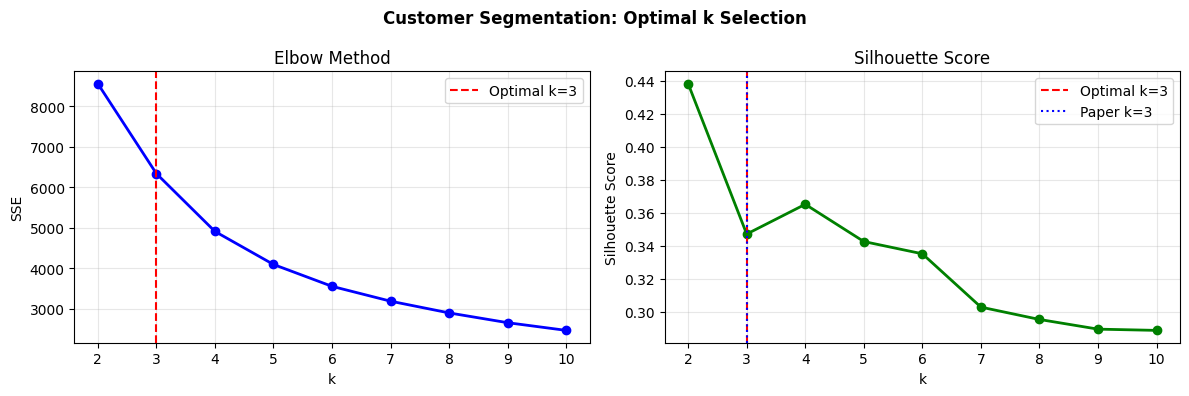

[Saved] optimal_k_selection.png


In [4]:
# =============================================================================
# CELL 3: CUSTOMER SEGMENTATION
#   3A — Paper : Fixed k=3
#   3B — New   : Optimal k via Elbow + Silhouette
# =============================================================================

print("\n" + "=" * 70)
print("CELL 3: CUSTOMER SEGMENTATION")
print("=" * 70)

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice"    : "nunique",
    "TotalPrice" : "sum",
    "Quantity"   : "sum"
}).reset_index()
rfm.columns = ["CustomerID","Recency","Frequency","Monetary","TotalQty"]

cust_region = (
    df.groupby("Customer ID")["Region"]
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={"Customer ID":"CustomerID"})
)
rfm = rfm.merge(cust_region, on="CustomerID", how="left")

rfm_log    = np.log1p(rfm[["Recency","Frequency","Monetary"]])
scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm_log)

# ── 3A: Paper — fixed k=3 ────────────────────────────────────────────────
print("\n--- 3A: Paper approach (fixed k=3) ---")
km3        = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
labels_k3  = km3.fit_predict(rfm_scaled)
sil_k3     = silhouette_score(rfm_scaled, labels_k3)
dbi_k3     = davies_bouldin_score(rfm_scaled, labels_k3)
chi_k3     = calinski_harabasz_score(rfm_scaled, labels_k3)
print(f"  Silhouette     : {sil_k3:.4f}")
print(f"  Davies-Bouldin : {dbi_k3:.4f}")
print(f"  Calinski-Harab.: {chi_k3:.2f}")
SEG_ORDER_PAPER = ["Good","Moderate","Normal"]

# ── 3B: New — optimal k ──────────────────────────────────────────────────
print("\n--- 3B: New approach (optimal k via Elbow + Silhouette) ---")
sse_list      = []
sil_list_cust = []
k_range_cust  = range(2, 11)

for k in k_range_cust:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(rfm_scaled)
    sse_list.append(km.inertia_)
    sil_list_cust.append(silhouette_score(rfm_scaled, lbl))
    print(f"  k={k:>2}: SSE={km.inertia_:>10.2f}  "
          f"Silhouette={sil_list_cust[-1]:.4f}")

optimal_k  = max(list(k_range_cust)[np.argmax(sil_list_cust)], 3)
sil_optk   = silhouette_score(rfm_scaled,
             KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE,
                    n_init=10).fit_predict(rfm_scaled))
dbi_optk   = davies_bouldin_score(rfm_scaled,
             KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE,
                    n_init=10).fit_predict(rfm_scaled))
chi_optk   = calinski_harabasz_score(rfm_scaled,
             KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE,
                    n_init=10).fit_predict(rfm_scaled))

print(f"\n=> Optimal k = {optimal_k}")
print(f"  Silhouette     : {sil_optk:.4f}")
print(f"  Davies-Bouldin : {dbi_optk:.4f}")
print(f"  Calinski-Harab.: {chi_optk:.2f}")

km_final       = KMeans(n_clusters=optimal_k,
                        random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = km_final.fit_predict(rfm_scaled)
centroids_new  = rfm.groupby("Cluster")[
    ["Recency","Frequency","Monetary"]].mean()
centroids_new["Score"] = (-centroids_new["Recency"]
                          + centroids_new["Frequency"]
                          + centroids_new["Monetary"])
centroids_new  = centroids_new.sort_values("Score", ascending=False)

if optimal_k == 3:
    labels_list = ["Good","Moderate","Normal"]
elif optimal_k == 4:
    labels_list = ["Premium","Good","Moderate","Normal"]
else:
    labels_list = (["Premium","Good","Moderate","At-Risk","Normal"]
                   + [f"Tier-{i}" for i in range(6, optimal_k+1)])
    labels_list = labels_list[:optimal_k]

names_map_new  = {c: l for c, l in zip(centroids_new.index, labels_list)}
rfm["Segment"] = rfm["Cluster"].map(names_map_new)
SEG_ORDER_NEW  = labels_list
REGION_ORDER   = ["Local","Europe","Asian"]

print(f"\nSegment distribution (k={optimal_k}):")
print(rfm["Segment"].value_counts().reindex(labels_list).to_string())

# ── Clustering Quality Comparison ────────────────────────────────────────
print("\n--- Clustering Quality: Paper (k=3) vs New (k=optimal) ---")
clust_eval = pd.DataFrame([
    {"Approach": "Paper (k=3)",
     "k": 3,
     "Silhouette"        : round(sil_k3,   4),
     "Davies_Bouldin"    : round(dbi_k3,   4),
     "Calinski_Harabasz" : round(chi_k3,   2)},
    {"Approach": f"New (k={optimal_k})",
     "k": optimal_k,
     "Silhouette"        : round(sil_optk, 4),
     "Davies_Bouldin"    : round(dbi_optk, 4),
     "Calinski_Harabasz" : round(chi_optk, 2)},
]).set_index("Approach")

print(clust_eval.to_string())

d_sil = sil_optk  - sil_k3
d_dbi = dbi_optk  - dbi_k3
d_chi = chi_optk  - chi_k3

print(f"\nDelta (New − Paper):")
print(f"  Silhouette     : {d_sil:+.4f}  {'✓ better' if d_sil > 0 else '✗ worse'}")
print(f"  Davies-Bouldin : {d_dbi:+.4f}  {'✓ better' if d_dbi < 0 else '✗ worse'}")
print(f"  Calinski-Harab.: {d_chi:+.2f}  {'✓ better' if d_chi > 0 else '✗ worse'}")

clust_eval.to_csv(f"{OUT_DIR}/eval_clustering_comparison.csv")
print(f"\n[Saved] eval_clustering_comparison.csv")

# ── Elbow + Silhouette plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(list(k_range_cust), sse_list, "bo-", linewidth=2)
ax.axvline(x=optimal_k, color="r", linestyle="--",
           label=f"Optimal k={optimal_k}")
ax.set_xlabel("k"); ax.set_ylabel("SSE")
ax.set_title("Elbow Method"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(list(k_range_cust), sil_list_cust, "go-", linewidth=2)
ax.axvline(x=optimal_k, color="r", linestyle="--",
           label=f"Optimal k={optimal_k}")
ax.axvline(x=3, color="b", linestyle=":",
           label="Paper k=3")
ax.set_xlabel("k"); ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Customer Segmentation: Optimal k Selection",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/optimal_k_selection.png", dpi=150)
plt.show()
print("[Saved] optimal_k_selection.png")



In [5]:
# =============================================================================
# CELL 4: HELPER FUNCTIONS  (shared)
# =============================================================================

print("\n" + "=" * 70)
print("CELL 4: HELPER FUNCTIONS")
print("=" * 70)

rfm_cols_new   = ["CustomerID","Recency","Frequency",
                  "Monetary","TotalQty","Segment","Region"]
FEATURES_PAPER = ([f"lag{i}" for i in range(1, WINDOW_SIZE+1)]
                  + ["Recency","Frequency","Monetary","Total_Qty"])
FEATURES_NEW   = ([f"lag{i}" for i in range(1, WINDOW_SIZE+1)]
                  + ["Recency","Frequency","Monetary","TotalQty"])

# ── Giới hạn kích thước ───────────────────────────────────────────────────
MAX_ROWS_PER_GROUP     = 300_000
MIN_TRANS_PER_PAIR     = 2
TOP_PRODUCTS_PER_GROUP = 50

def build_model_df_efficient(prod_df,
                              rfm_df,
                              rfm_cols,
                              all_periods,
                              window_size,
                              stock_col=None,
                              max_rows=MAX_ROWS_PER_GROUP):
    """
    Efficient version dùng cho New approach (group lớn).
    Pivot → lag thay vì cross join.
    """
    prod_df              = prod_df.copy()
    prod_df["YearMonth"] = prod_df["YearMonth"].astype(str)

    if stock_col is None:
        grp_cols = ["Customer ID","YearMonth"]
    else:
        grp_cols = ["Customer ID","StockCode","YearMonth"]

    monthly = (
        prod_df.groupby(grp_cols)
        .agg(Purchased=("Invoice","nunique"),
             TotalPrice=("TotalPrice","sum"),
             Quantity  =("Quantity","sum"))
        .reset_index()
    )
    monthly["Purchased"] = (monthly["Purchased"] > 0).astype(int)

    # ── Pivot to wide ─────────────────────────────────────────────────────
    if stock_col is None:
        pivot = monthly.pivot_table(
            index   ="Customer ID",
            columns ="YearMonth",
            values  ="Purchased",
            fill_value=0
        )
    else:
        monthly["entity"] = (
            monthly["Customer ID"].astype(str)
            + "_"
            + monthly["StockCode"].astype(str)
        )
        pivot = monthly.pivot_table(
            index   ="entity",
            columns ="YearMonth",
            values  ="Purchased",
            fill_value=0
        )

    # Đảm bảo đủ tất cả periods
    for col in [p for p in all_periods if p not in pivot.columns]:
        pivot[col] = 0
    pivot = pivot[all_periods]

    # ── Build lag records ─────────────────────────────────────────────────
    periods = list(all_periods)
    records = []
    for t_idx in range(window_size, len(periods)):
        target_period = periods[t_idx]
        lag_vals      = {
            f"lag{lag}": pivot[periods[t_idx - lag]].values
            for lag in range(1, window_size + 1)
        }
        lag_vals["Purchased"] = pivot[target_period].values
        lag_vals["YearMonth"] = target_period
        lag_vals["entity"]    = pivot.index.tolist()
        records.append(pd.DataFrame(lag_vals))

    model_df = pd.concat(records, ignore_index=True)

    # ── Parse entity → CustomerID (+ StockCode) ───────────────────────────
    if stock_col is None:
        model_df = model_df.rename(columns={"entity":"CustomerID"})
    else:
        model_df[["CustomerID","StockCode"]] = (
            model_df["entity"]
            .str.split("_", n=1, expand=True)
        )
        model_df = model_df.drop(columns=["entity"])

    model_df["CustomerID"] = model_df["CustomerID"].astype(str)

    # ── Merge RFM ─────────────────────────────────────────────────────────
    rfm_merge               = rfm_df[rfm_cols].copy()
    rfm_merge["CustomerID"] = rfm_merge["CustomerID"].astype(str)
    model_df                = model_df.merge(
        rfm_merge, on="CustomerID", how="left"
    )

    lag_cols = [f"lag{i}" for i in range(1, window_size + 1)]
    model_df = model_df.dropna(subset=lag_cols + ["Recency"])

    # ── Stratified sample nếu quá lớn ────────────────────────────────────
    if len(model_df) > max_rows:
        purchased     = model_df[model_df["Purchased"] == 1]
        not_purchased = model_df[model_df["Purchased"] == 0]
        ratio         = len(purchased) / len(model_df)
        n_pos         = int(max_rows * ratio)
        n_neg         = max_rows - n_pos
        model_df      = pd.concat([
            purchased.sample(
                min(n_pos, len(purchased)),
                random_state=RANDOM_STATE),
            not_purchased.sample(
                min(n_neg, len(not_purchased)),
                random_state=RANDOM_STATE)
        ]).sample(
            frac=1, random_state=RANDOM_STATE
        ).reset_index(drop=True)

    return model_df, lag_cols


def bootstrap_balance(X, y, random_state=42):
    combined = pd.concat([X, y], axis=1)
    target   = y.name
    majority = combined[combined[target] == 0]
    minority = combined[combined[target] == 1]
    if len(minority) == 0 or len(majority) == 0:
        return None, None
    if len(minority) < len(majority):
        minority_up = resample(minority, replace=True,
                               n_samples=len(majority),
                               random_state=random_state)
        balanced = pd.concat([majority, minority_up])
    else:
        majority_up = resample(majority, replace=True,
                               n_samples=len(minority),
                               random_state=random_state)
        balanced = pd.concat([minority, majority_up])
    balanced = balanced.sample(
        frac=1, random_state=random_state).reset_index(drop=True)
    return balanced[X.columns], balanced[target]


def evaluate_fold(clf, X_tr, y_tr, X_val, y_val):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_val)
    y_prob = clf.predict_proba(X_val)[:, 1]
    try:
        auc = roc_auc_score(y_val, y_prob)
    except Exception:
        auc = 0.5
    return {
        "accuracy" : accuracy_score(y_val, y_pred),
        "f1"       : f1_score(y_val, y_pred, zero_division=0),
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall"   : recall_score(y_val, y_pred, zero_division=0),
        "auc"      : auc,
        "mcc"      : matthews_corrcoef(y_val, y_pred),
    }


def run_cv(clf, X, y, cv_obj, is_stratified=False):
    fold_m     = {k: [] for k in
                  ["accuracy","f1","precision","recall","auc","mcc"]}
    split_iter = (cv_obj.split(X, y) if is_stratified
                  else cv_obj.split(X))
    for tr, val in split_iter:
        m = evaluate_fold(clf,
                          X.iloc[tr], y.iloc[tr],
                          X.iloc[val], y.iloc[val])
        for k in fold_m:
            fold_m[k].append(m[k])
    return {
        "mean": {k: np.mean(v) for k, v in fold_m.items()},
        "std" : {k: np.std(v)  for k, v in fold_m.items()}
    }


def make_de_objective(data, seg_order, region_order=None):
    data    = data.copy()
    n_segs  = len(seg_order)
    use_reg = region_order is not None
    n_regs  = len(region_order) if use_reg else 0

    def objective(params):
        r_max = params[0]
        f_min = params[1]
        m_min = params[2]
        seg   = seg_order[int(round(params[3])) % n_segs]
        mask  = (
            (data["Recency"]   <= r_max) &
            (data["Frequency"] >= f_min) &
            (data["Monetary"]  >= m_min) &
            (data["Segment"]   == seg)
        )
        if use_reg:
            reg  = region_order[int(round(params[4])) % n_regs]
            mask = mask & (data["Region"] == reg)
        sel = data[mask]
        if len(sel) < 5:
            return 0.0
        return -(sel["Pred_Prob"].mean() * np.sqrt(len(sel)))
    return objective


# ── Checkpoint helpers ────────────────────────────────────────────────────
import pickle

def save_checkpoint(name, obj):
    path = f"{OUT_DIR}/ckpt_{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"  [Checkpoint saved] {path}")

def load_checkpoint(name):
    path = f"{OUT_DIR}/ckpt_{name}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            obj = pickle.load(f)
        print(f"  [Checkpoint loaded] {path}")
        return obj, True
    return None, False


DE_KWARGS = dict(
    seed=RANDOM_STATE, maxiter=300, popsize=10,
    polish=True, tol=1e-4,
    mutation=(0.5, 1.0), recombination=0.7
)

print("All helper functions defined.")
print(f"  MAX_ROWS_PER_GROUP     : {MAX_ROWS_PER_GROUP:,}")
print(f"  MIN_TRANS_PER_PAIR     : {MIN_TRANS_PER_PAIR}")
print(f"  TOP_PRODUCTS_PER_GROUP : {TOP_PRODUCTS_PER_GROUP}")



CELL 4: HELPER FUNCTIONS
All helper functions defined.
  MAX_ROWS_PER_GROUP     : 300,000
  MIN_TRANS_PER_PAIR     : 2
  TOP_PRODUCTS_PER_GROUP : 50



CELL 5A: BUILD REPRESENTATIVE GROUP DATA
Filtered to top 50 products (was 619)
Valid pairs (≥2 trans): 14,117
Build time   : 1.0s
Model df rows: 268,223

Representative group : Group_1
N customers          : 5,719
Raw rows             : 268,223
Purchase rate (raw)  : 15.4%  (Pos=41,195.0, Neg=227,028)
Balanced samples     : 454,056

Sample sizes:
  X_bal_r    : 454,056  ← full balanced
  X_bal_tune : 5,000  ← HP search  (5B)
  X_bal_eval : 30,000  ← Comparison (5C)
  X_bal_sens : 10,000  ← Sensitivity (5D)

CELL 5B: RANDOMIZED SEARCH CV
Scoring=F1 | CV=TimeSeriesSplit(5) | Sample=5,000

--- Benchmark (2,000 rows sample) ---
Model              1fit   Fits   Est(seq)  Est(/2core)
───────────────────────────────────────────────────────
  DecisionTree      0.01s    150         2s          1s (~0.0min)
  ANN               0.09s     40         4s          2s (~0.0min)
  GBT               0.33s     75        25s         14s (~0.2min)
───────────────────────────────────────────────────────
  

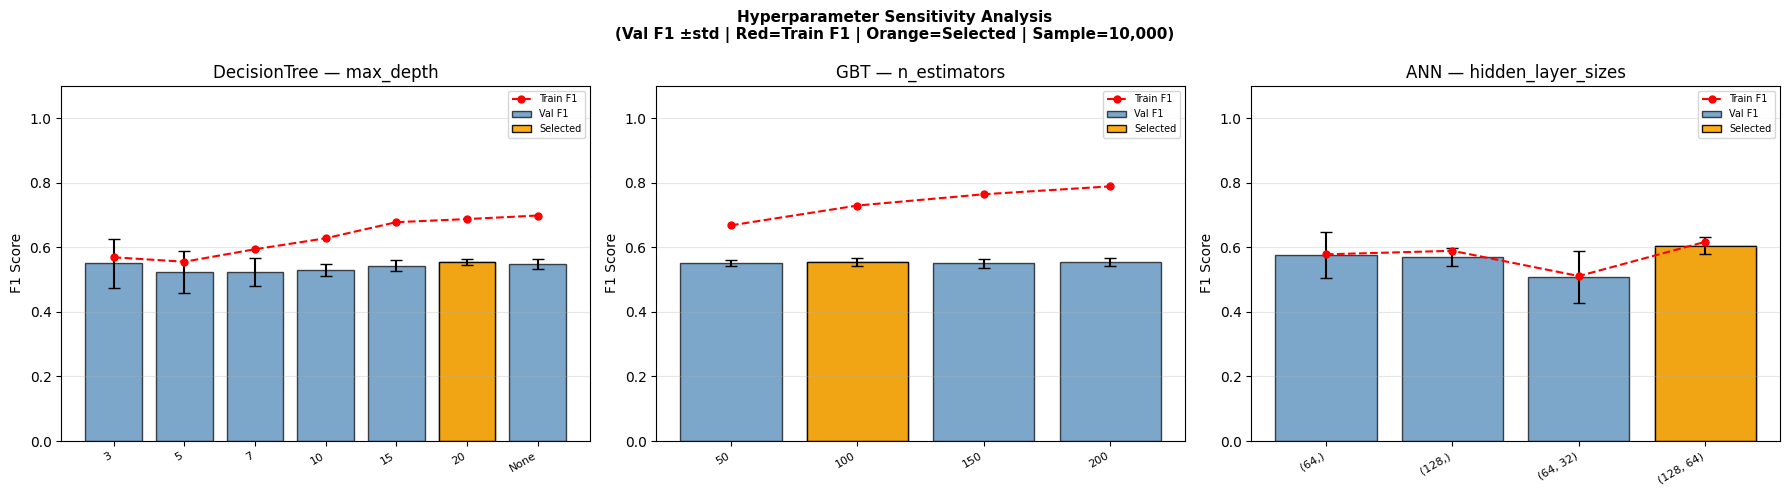

[Saved] sensitivity_analysis.png

Cell 5 Summary:
  X_bal_r    : 454,056 (full balanced)
  X_bal_tune : 5,000 (5B HP search)
  X_bal_eval : 30,000 (5C comparison)
  X_bal_sens : 10,000 (5D sensitivity)
  best_params: ['DecisionTree', 'ANN', 'GBT']
    DecisionTree: {'criterion': 'gini', 'max_depth': 19, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 31}
    ANN: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (64,), 'batch_size': 128, 'alpha': 0.01, 'activation': 'relu'}
    GBT: {'learning_rate': np.float64(0.10772345640553725), 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 8, 'n_estimators': 57, 'subsample': np.float64(0.6137554084460873)}


In [6]:
# =============================================================================
# CELL 5: HYPERPARAMETER TUNING
#   5A — Build representative group data
#   5B — RandomizedSearchCV
#   5C — Default vs Tuned comparison
#   5D — Sensitivity analysis
# =============================================================================

print("\n" + "=" * 70)
print("CELL 5A: BUILD REPRESENTATIVE GROUP DATA")
print("=" * 70)

# ── Tìm representative group ──────────────────────────────────────────────
group_sizes = {}
for gid in range(optimal_product_groups):
    stocks = pareto_products[
        pareto_products["ProductGroup"] == gid
    ]["StockCode"].tolist()
    n_cust = df_pareto[
        df_pareto["StockCode"].isin(stocks)
    ]["Customer ID"].nunique()
    group_sizes[gid] = n_cust

repr_group  = max(group_sizes, key=group_sizes.get)
repr_stocks = pareto_products[
    pareto_products["ProductGroup"] == repr_group
]["StockCode"].tolist()
repr_raw    = df_pareto[
    df_pareto["StockCode"].isin(repr_stocks)
].copy()

# ── Filter top products ───────────────────────────────────────────────────
if len(repr_stocks) > TOP_PRODUCTS_PER_GROUP:
    top_stocks = (
        repr_raw.groupby("StockCode")["TotalPrice"]
        .sum()
        .nlargest(TOP_PRODUCTS_PER_GROUP)
        .index.tolist()
    )
    repr_raw = repr_raw[
        repr_raw["StockCode"].isin(top_stocks)
    ].copy()
    print(f"Filtered to top {TOP_PRODUCTS_PER_GROUP} products "
          f"(was {len(repr_stocks)})")

# ── Filter pairs ≥ MIN_TRANS_PER_PAIR ────────────────────────────────────
pair_counts = (
    repr_raw.groupby(["Customer ID","StockCode"])
    ["Invoice"].nunique()
    .reset_index()
    .rename(columns={"Invoice":"n_trans"})
)
valid_pairs = pair_counts[
    pair_counts["n_trans"] >= MIN_TRANS_PER_PAIR
][["Customer ID","StockCode"]]

repr_raw = repr_raw.merge(
    valid_pairs,
    on=["Customer ID","StockCode"],
    how="inner"
)
print(f"Valid pairs (≥{MIN_TRANS_PER_PAIR} trans): "
      f"{len(valid_pairs):,}")

# ── Build model_df ────────────────────────────────────────────────────────
t0 = time.time()
repr_model_df, _ = build_model_df_efficient(
    repr_raw,
    rfm[rfm_cols_new],
    rfm_cols_new,
    all_periods,
    WINDOW_SIZE,
    stock_col="StockCode",
    max_rows=MAX_ROWS_PER_GROUP
)
print(f"Build time   : {time.time()-t0:.1f}s")
print(f"Model df rows: {len(repr_model_df):,}")

X_repr           = repr_model_df[FEATURES_NEW]
y_repr           = repr_model_df["Purchased"]
X_bal_r, y_bal_r = bootstrap_balance(
    X_repr, y_repr, random_state=RANDOM_STATE)

print(f"\nRepresentative group : Group_{repr_group}")
print(f"N customers          : {group_sizes[repr_group]:,}")
print(f"Raw rows             : {len(repr_model_df):,}")
print(f"Purchase rate (raw)  : {y_repr.mean():.1%}  "
      f"(Pos={y_repr.sum():,}, "
      f"Neg={(y_repr==0).sum():,})")
print(f"Balanced samples     : {len(X_bal_r):,}")

# ── Tạo các sample size khác nhau ────────────────────────────────────────
MAX_TUNE_SAMPLES = 5_000    # HP search   — nhanh nhất
MAX_SENS_SAMPLES = 10_000   # Sensitivity — cần đủ variance
MAX_EVAL_SAMPLES = 30_000   # 5C eval     — cân bằng speed/accuracy

def make_sample(X, y, n, seed=RANDOM_STATE):
    """Stratified sample giữ tỉ lệ class."""
    if len(X) <= n:
        return X.copy(), y.copy()
    idx = np.random.RandomState(seed).choice(
        len(X), n, replace=False)
    return (X.iloc[idx].reset_index(drop=True),
            y.iloc[idx].reset_index(drop=True))

X_bal_tune, y_bal_tune = make_sample(
    X_bal_r, y_bal_r, MAX_TUNE_SAMPLES, RANDOM_STATE)
X_bal_sens, y_bal_sens = make_sample(
    X_bal_r, y_bal_r, MAX_SENS_SAMPLES, RANDOM_STATE)
X_bal_eval, y_bal_eval = make_sample(
    X_bal_r, y_bal_r, MAX_EVAL_SAMPLES, RANDOM_STATE)

print(f"\nSample sizes:")
print(f"  X_bal_r    : {len(X_bal_r):,}  ← full balanced")
print(f"  X_bal_tune : {len(X_bal_tune):,}  ← HP search  (5B)")
print(f"  X_bal_eval : {len(X_bal_eval):,}  ← Comparison (5C)")
print(f"  X_bal_sens : {len(X_bal_sens):,}  ← Sensitivity (5D)")

# =============================================================================
print("\n" + "=" * 70)
print("CELL 5B: RANDOMIZED SEARCH CV")
print(f"Scoring=F1 | CV=TimeSeriesSplit(5) | "
      f"Sample={len(X_bal_tune):,}")
print("=" * 70)

tscv_tune = TimeSeriesSplit(n_splits=5)

param_spaces = {
    "DecisionTree": {
        "estimator": DecisionTreeClassifier(
            random_state=RANDOM_STATE),
        "params": {
            "max_depth"        : randint(3, 20),
            "min_samples_split": randint(2, 50),
            "min_samples_leaf" : randint(1, 20),
            "criterion"        : ["gini","entropy"],
            "max_features"     : ["sqrt","log2",None]
        },
        "n_iter": 30
    },
    "ANN": {
        "estimator": MLPClassifier(
            max_iter            = 200,
            random_state        = RANDOM_STATE,
            early_stopping      = True,
            validation_fraction = 0.1,
            n_iter_no_change    = 10,
            tol                 = 1e-3
        ),
        "params": {
            "hidden_layer_sizes": [(64,),(128,),
                                   (64,32),(128,64)],
            "activation"        : ["relu"],
            "alpha"             : [1e-4, 1e-3, 1e-2],
            "learning_rate_init": [1e-3, 5e-3],
            "batch_size"        : [64, 128]
        },
        "n_iter": 8
    },
    "GBT": {
        "estimator": GradientBoostingClassifier(
            random_state=RANDOM_STATE),
        "params": {
            "n_estimators"     : randint(50, 200),  # 300→200
            "max_depth"        : randint(2, 6),     # 8→6
            "learning_rate"    : uniform(0.05, 0.25),
            "min_samples_split": randint(2, 20),
            "subsample"        : uniform(0.6, 0.4),
            "max_features"     : ["sqrt","log2"]    # bỏ None
        },
        "n_iter": 15                                # 30→15
    }
}

# ── Benchmark trước khi tune ──────────────────────────────────────────────
print("\n--- Benchmark (2,000 rows sample) ---")
print(f"{'Model':<15} {'1fit':>7} {'Fits':>6} "
      f"{'Est(seq)':>10} {'Est(/2core)':>12}")
print("─" * 55)

X_bm = X_bal_tune.iloc[:2000]
y_bm = y_bal_tune.iloc[:2000]

total_est = 0
for name, config in param_spaces.items():
    bm_clf = config["estimator"]
    t0     = time.time()
    bm_clf.fit(X_bm, y_bm)
    t_fit  = time.time() - t0
    n_fits = config["n_iter"] * tscv_tune.n_splits
    est_s  = t_fit * n_fits
    est_p  = est_s / 1.8
    total_est += est_p
    print(f"  {name:<15} {t_fit:>6.2f}s "
          f"{n_fits:>6} "
          f"{est_s:>9.0f}s "
          f"{est_p:>10.0f}s (~{est_p/60:.1f}min)")

print("─" * 55)
print(f"  {'TOTAL':<15} {'':>7} {'':>6} "
      f"{'':>10} {total_est:>10.0f}s "
      f"(~{total_est/60:.1f}min)")

# ── RandomizedSearchCV ────────────────────────────────────────────────────
best_params    = {}
tuning_summary = []

for name, config in param_spaces.items():
    print(f"\n{'─'*50}")
    print(f"Tuning {name} "
          f"({config['n_iter']} iter × "
          f"{tscv_tune.n_splits} folds = "
          f"{config['n_iter']*tscv_tune.n_splits} fits) ...")
    set_global_seed(RANDOM_STATE)
    t0 = time.time()

    search = RandomizedSearchCV(
        estimator          = config["estimator"],
        param_distributions= config["params"],
        n_iter             = config["n_iter"],
        cv                 = tscv_tune,
        scoring            = "f1",
        n_jobs             = -1,
        random_state       = RANDOM_STATE,
        refit              = True,
        return_train_score = True,
        verbose            = 0
    )
    search.fit(X_bal_tune, y_bal_tune)   # ← 5K rows
    elapsed = time.time() - t0

    best_params[name] = search.best_params_
    tuning_summary.append({
        "Model"      : name,
        "Best_F1"    : round(search.best_score_, 4),
        "Best_Params": str(search.best_params_),
        "Runtime_s"  : round(elapsed, 1),
        "N_fits"     : config["n_iter"] * tscv_tune.n_splits,
        "Sample_size": len(X_bal_tune)
    })

    print(f"  Best F1  : {search.best_score_:.4f}")
    print(f"  Runtime  : {elapsed:.1f}s "
          f"({elapsed/config['n_iter']/tscv_tune.n_splits:.2f}s/fit)")
    print(f"  Best params:")
    for k, v in search.best_params_.items():
        print(f"    {k:<25}: {v}")

    cv_res = pd.DataFrame(search.cv_results_)
    top5   = (cv_res
              .sort_values("mean_test_score", ascending=False)
              .head(5)[["mean_test_score","std_test_score",
                         "mean_train_score"]])
    print(f"  Top-5 configs:")
    for _, row in top5.iterrows():
        gap = row["mean_train_score"] - row["mean_test_score"]
        print(f"    Val={row['mean_test_score']:.4f} "
              f"±{row['std_test_score']:.4f}  "
              f"Train={row['mean_train_score']:.4f}  "
              f"Gap={gap:.4f}")

tuning_df = pd.DataFrame(tuning_summary).set_index("Model")
tuning_df.to_csv(f"{OUT_DIR}/hyperparameter_tuning.csv")
print(f"\n[Saved] hyperparameter_tuning.csv")

# =============================================================================
print("\n" + "=" * 70)
print("CELL 5C: DEFAULT vs TUNED COMPARISON")
print(f"Sample={len(X_bal_eval):,} | "
      f"TimeSeriesSplit({N_FOLDS})")
print("=" * 70)

def build_default_models(rs=RANDOM_STATE):
    return {
        "DecisionTree": DecisionTreeClassifier(
            max_depth=10,
            random_state=rs),
        "ANN"         : MLPClassifier(
            hidden_layer_sizes  = (64,32),
            max_iter            = 200,
            early_stopping      = True,
            n_iter_no_change    = 10,
            tol                 = 1e-3,
            random_state        = rs),
        "GBT"         : GradientBoostingClassifier(
            n_estimators = 100,
            max_depth    = 4,
            random_state = rs)
    }

def build_tuned_models(bp, rs=RANDOM_STATE):
    return {
        "DecisionTree": DecisionTreeClassifier(
            **bp["DecisionTree"],
            random_state=rs),
        "ANN"         : MLPClassifier(
            **bp["ANN"],
            max_iter         = 200,
            early_stopping   = True,
            n_iter_no_change = 10,
            tol              = 1e-3,
            random_state     = rs),
        "GBT"         : GradientBoostingClassifier(
            **bp["GBT"],
            random_state=rs)
    }

tscv_eval  = TimeSeriesSplit(n_splits=N_FOLDS)
hp_comp    = []
model_keys = ["DecisionTree","ANN","GBT"]

for setting, factory in [("Default", build_default_models),
                          ("Tuned",   build_tuned_models)]:
    models_hp = (factory(RANDOM_STATE) if setting == "Default"
                 else factory(best_params, RANDOM_STATE))

    for name, clf in models_hp.items():
        set_global_seed(RANDOM_STATE)
        t0  = time.time()
        res = run_cv(clf, X_bal_eval, y_bal_eval,
                     tscv_eval, is_stratified=False)
        elapsed = time.time() - t0
        hp_comp.append({
            "Setting"  : setting,
            "Model"    : name,
            "Accuracy" : round(res["mean"]["accuracy"], 4),
            "F1"       : round(res["mean"]["f1"],       4),
            "Precision": round(res["mean"]["precision"],4),
            "Recall"   : round(res["mean"]["recall"],   4),
            "AUC"      : round(res["mean"]["auc"],      4),
            "MCC"      : round(res["mean"]["mcc"],      4),
            "F1_std"   : round(res["std"]["f1"],        4),
        })
        print(f"  {setting:<8} {name:<15}: "
              f"F1={res['mean']['f1']:.4f}  "
              f"Acc={res['mean']['accuracy']:.4f}  "
              f"AUC={res['mean']['auc']:.4f}  "
              f"({elapsed:.1f}s)")

hp_comp_df = pd.DataFrame(hp_comp)

print(f"\n{'Model':<15} {'Setting':<10} "
      f"{'Acc':>8} {'F1':>8} {'AUC':>8} "
      f"{'MCC':>8} {'F1_std':>8}")
print("─" * 65)

for name in model_keys:
    for setting in ["Default","Tuned"]:
        row    = hp_comp_df[
            (hp_comp_df["Model"]   == name) &
            (hp_comp_df["Setting"] == setting)
        ].iloc[0]
        marker = " ←" if setting == "Tuned" else ""
        print(f"  {name:<15} {setting:<10} "
              f"{row['Accuracy']:>8.4f} {row['F1']:>8.4f} "
              f"{row['AUC']:>8.4f} {row['MCC']:>8.4f} "
              f"{row['F1_std']:>8.4f}{marker}")
    print()

print("Delta (Tuned − Default):")
print(f"{'Model':<15} {'ΔAcc':>8} {'ΔF1':>8} "
      f"{'ΔAUC':>8} {'ΔMCC':>8}")
print("─" * 48)

for name in model_keys:
    def_r   = hp_comp_df[
        (hp_comp_df["Model"]   == name) &
        (hp_comp_df["Setting"] == "Default")
    ].iloc[0]
    tuned_r = hp_comp_df[
        (hp_comp_df["Model"]   == name) &
        (hp_comp_df["Setting"] == "Tuned")
    ].iloc[0]
    d_acc = tuned_r["Accuracy"] - def_r["Accuracy"]
    d_f1  = tuned_r["F1"]       - def_r["F1"]
    d_auc = tuned_r["AUC"]      - def_r["AUC"]
    d_mcc = tuned_r["MCC"]      - def_r["MCC"]
    print(f"  {name:<15} "
          f"{d_acc:>+8.4f} {d_f1:>+8.4f} "
          f"{d_auc:>+8.4f} {d_mcc:>+8.4f}")

hp_comp_df.to_csv(f"{OUT_DIR}/hyperparameter_comparison.csv",
                  index=False)
print(f"\n[Saved] hyperparameter_comparison.csv")

# =============================================================================
print("\n" + "=" * 70)
print("CELL 5D: SENSITIVITY ANALYSIS")
print(f"Sample={len(X_bal_sens):,} | "
      f"TimeSeriesSplit(5)")
print("=" * 70)

sens_results = []

# ── DecisionTree: max_depth ───────────────────────────────────────────────
print("\n--- DecisionTree: max_depth ---")
print(f"{'max_depth':>12} {'F1_val':>10} "
      f"{'F1_std':>10} {'Overfit_gap':>12}")
print("─" * 48)

for depth in [3, 5, 7, 10, 15, 20, None]:
    set_global_seed(RANDOM_STATE)
    extra = {k: v for k, v in best_params["DecisionTree"].items()
             if k != "max_depth"}
    clf   = DecisionTreeClassifier(
        max_depth    = depth,
        random_state = RANDOM_STATE,
        **extra)
    f1v, f1t = [], []
    for tr, val in tscv_tune.split(X_bal_sens):
        clf.fit(X_bal_sens.iloc[tr], y_bal_sens.iloc[tr])
        f1v.append(f1_score(
            y_bal_sens.iloc[val],
            clf.predict(X_bal_sens.iloc[val]),
            zero_division=0))
        f1t.append(f1_score(
            y_bal_sens.iloc[tr],
            clf.predict(X_bal_sens.iloc[tr]),
            zero_division=0))
    mean_f1 = np.mean(f1v)
    std_f1  = np.std(f1v)
    gap     = np.mean(f1t) - mean_f1
    dlabel  = str(depth) if depth else "None"
    best_d  = best_params["DecisionTree"].get("max_depth")
    marker  = " ← selected" if depth == best_d else ""
    print(f"  {dlabel:>10} {mean_f1:>10.4f} "
          f"{std_f1:>10.4f} {gap:>12.4f}{marker}")
    sens_results.append({
        "Model"      : "DecisionTree",
        "Param"      : "max_depth",
        "Value"      : dlabel,
        "F1"         : mean_f1,
        "F1_std"     : std_f1,
        "Overfit_gap": gap
    })

# ── GBT: n_estimators ────────────────────────────────────────────────────
print("\n--- GBT: n_estimators ---")
print(f"{'n_estimators':>14} {'F1_val':>10} "
      f"{'F1_std':>10} {'Overfit_gap':>12}")
print("─" * 50)

for n_est in [50, 100, 150, 200]:     # 6 values → 4 values
    set_global_seed(RANDOM_STATE)
    extra = {k: v for k, v in best_params["GBT"].items()
             if k != "n_estimators"}
    clf   = GradientBoostingClassifier(
        n_estimators = n_est,
        random_state = RANDOM_STATE,
        **extra)
    f1v, f1t = [], []
    for tr, val in tscv_tune.split(X_bal_sens):
        clf.fit(X_bal_sens.iloc[tr], y_bal_sens.iloc[tr])
        f1v.append(f1_score(
            y_bal_sens.iloc[val],
            clf.predict(X_bal_sens.iloc[val]),
            zero_division=0))
        f1t.append(f1_score(
            y_bal_sens.iloc[tr],
            clf.predict(X_bal_sens.iloc[tr]),
            zero_division=0))
    mean_f1 = np.mean(f1v)
    std_f1  = np.std(f1v)
    gap     = np.mean(f1t) - mean_f1
    best_n  = best_params["GBT"].get("n_estimators")
    marker  = " ← selected" if n_est == best_n else ""
    print(f"  {n_est:>12} {mean_f1:>10.4f} "
          f"{std_f1:>10.4f} {gap:>12.4f}{marker}")
    sens_results.append({
        "Model"      : "GBT",
        "Param"      : "n_estimators",
        "Value"      : str(n_est),
        "F1"         : mean_f1,
        "F1_std"     : std_f1,
        "Overfit_gap": gap
    })

# ── ANN: hidden_layer_sizes ───────────────────────────────────────────────
print("\n--- ANN: hidden_layer_sizes ---")
print(f"{'architecture':>18} {'F1_val':>10} "
      f"{'F1_std':>10} {'Overfit_gap':>12}")
print("─" * 55)

architectures = [
    (64,),(128,),
    (64,32),(128,64),
]                                      # 7 values → 4 values
best_arch = best_params["ANN"].get("hidden_layer_sizes")

for arch in architectures:
    set_global_seed(RANDOM_STATE)
    extra = {k: v for k, v in best_params["ANN"].items()
             if k != "hidden_layer_sizes"}
    clf   = MLPClassifier(
        hidden_layer_sizes = arch,
        max_iter           = 200,
        early_stopping     = True,
        n_iter_no_change   = 10,
        tol                = 1e-3,
        random_state       = RANDOM_STATE,
        **extra)
    f1v, f1t = [], []
    for tr, val in tscv_tune.split(X_bal_sens):
        clf.fit(X_bal_sens.iloc[tr], y_bal_sens.iloc[tr])
        f1v.append(f1_score(
            y_bal_sens.iloc[val],
            clf.predict(X_bal_sens.iloc[val]),
            zero_division=0))
        f1t.append(f1_score(
            y_bal_sens.iloc[tr],
            clf.predict(X_bal_sens.iloc[tr]),
            zero_division=0))
    mean_f1 = np.mean(f1v)
    std_f1  = np.std(f1v)
    gap     = np.mean(f1t) - mean_f1
    marker  = " ← selected" if arch == best_arch else ""
    print(f"  {str(arch):>16} {mean_f1:>10.4f} "
          f"{std_f1:>10.4f} {gap:>12.4f}{marker}")
    sens_results.append({
        "Model"      : "ANN",
        "Param"      : "hidden_layer_sizes",
        "Value"      : str(arch),
        "F1"         : mean_f1,
        "F1_std"     : std_f1,
        "Overfit_gap": gap
    })

sens_df = pd.DataFrame(sens_results)
sens_df.to_csv(f"{OUT_DIR}/sensitivity_analysis.csv", index=False)
print(f"\n[Saved] sensitivity_analysis.csv")

# ── Sensitivity plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model, param) in zip(axes, [
    ("DecisionTree", "max_depth"),
    ("GBT",          "n_estimators"),
    ("ANN",          "hidden_layer_sizes")
]):
    sub = sens_df[
        (sens_df["Model"] == model) &
        (sens_df["Param"] == param)
    ].reset_index(drop=True)
    x_s = np.arange(len(sub))

    ax.bar(x_s, sub["F1"],
           color="steelblue", edgecolor="black",
           alpha=0.7, label="Val F1")
    ax.errorbar(x_s, sub["F1"],
                yerr=sub["F1_std"],
                fmt="none", color="black", capsize=4)
    ax.plot(x_s, sub["F1"] + sub["Overfit_gap"],
            "r--o", markersize=5, label="Train F1")

    best_idx = sub["F1"].idxmax()
    ax.bar(best_idx, sub.loc[best_idx,"F1"],
           color="orange", edgecolor="black",
           alpha=0.9, label="Selected")

    ax.set_xticks(x_s)
    ax.set_xticklabels(sub["Value"],
                       rotation=30, ha="right", fontsize=8)
    ax.set_title(f"{model} — {param}")
    ax.set_ylabel("F1 Score")
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    "Hyperparameter Sensitivity Analysis\n"
    f"(Val F1 ±std | Red=Train F1 | Orange=Selected | "
    f"Sample={len(X_bal_sens):,})",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sensitivity_analysis.png", dpi=150)
plt.show()
print("[Saved] sensitivity_analysis.png")

# ── Summary Cell 5 ────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"Cell 5 Summary:")
print(f"  X_bal_r    : {len(X_bal_r):,} (full balanced)")
print(f"  X_bal_tune : {len(X_bal_tune):,} (5B HP search)")
print(f"  X_bal_eval : {len(X_bal_eval):,} (5C comparison)")
print(f"  X_bal_sens : {len(X_bal_sens):,} (5D sensitivity)")
print(f"  best_params: {list(best_params.keys())}")
for name, params in best_params.items():
    print(f"    {name}: {params}")



In [7]:
# =============================================================================
# CELL 6A: PAPER TRAINING
# StratifiedKFold (10-fold) | Default params | Per product | Accuracy criterion
# =============================================================================

print("\n" + "=" * 70)
print("CELL 6A: PAPER TRAINING")
print("StratifiedKFold | Default params | Per product | Accuracy criterion")
print("=" * 70)

skf_paper    = StratifiedKFold(n_splits=N_FOLDS,
                               shuffle=True, random_state=RANDOM_STATE)
paper_results  = {}
paper_best_models = {}
paper_test_data   = {}
paper_segments    = {}

for prod in paper_products:
    print(f"\n[{prod}]")

    prod_df = df[df["StockCode"] == prod].copy()
    n_cust  = prod_df["Customer ID"].nunique()

    if n_cust < 10:
        print(f"  SKIP: only {n_cust} customers")
        continue

    # ── Customer segmentation (k=3 per product) ───────────────────────────
    cust_prod = prod_df.groupby("Customer ID").agg(
        Recency   =("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency =("Invoice",     "nunique"),
        Monetary  =("TotalPrice",  "sum"),
        Quantity  =("Quantity",    "sum")
    ).reset_index()
    cust_prod.columns = ["CustomerID","Recency","Frequency","Monetary","Quantity"]

    if len(cust_prod) < 6:
        print(f"  SKIP: only {len(cust_prod)} customers for segmentation")
        continue

    rfm_p     = np.log1p(cust_prod[["Recency","Frequency","Monetary"]])
    scaler_p  = StandardScaler()
    rfm_ps    = scaler_p.fit_transform(rfm_p)

    km_p      = KMeans(n_clusters=N_CLUSTERS_PAPER,
                       random_state=RANDOM_STATE, n_init=10)
    cust_prod["Cluster"] = km_p.fit_predict(rfm_ps)

    # Map clusters → Good/Moderate/Normal by score
    centroids_p = cust_prod.groupby("Cluster")[
        ["Recency","Frequency","Monetary"]].mean()
    centroids_p["Score"] = (-centroids_p["Recency"]
                            + centroids_p["Frequency"]
                            + centroids_p["Monetary"])
    centroids_p = centroids_p.sort_values("Score", ascending=False)
    seg_map_p   = {c: l for c, l in zip(
        centroids_p.index, SEG_ORDER_PAPER)}
    cust_prod["Segment"] = cust_prod["Cluster"].map(seg_map_p)
    paper_segments[prod] = cust_prod

    # ── Build model_df (product-level) ────────────────────────────────────
    rfm_prod_cols = ["CustomerID","Recency","Frequency","Monetary",
                     "Quantity","Segment"]
    try:
        model_df, lag_cols = build_model_df_efficient(
            prod_df,
            cust_prod[rfm_prod_cols],
            rfm_prod_cols,
            all_periods,
            WINDOW_SIZE,
            stock_col=None,
            max_rows=100_000
        )
    except Exception as e:
        print(f"  SKIP: build_model_df failed — {e}")
        continue

    if len(model_df) < 50:
        print(f"  SKIP: only {len(model_df)} rows")
        continue

    # Encode segment as ordinal (paper uses RFM as numeric features)
    seg_ord = {"Good": 2, "Moderate": 1, "Normal": 0}
    model_df["Segment_Code"] = model_df["Segment"].map(seg_ord).fillna(0)

    FEATURES_PAPER_PROD = lag_cols + [
        "Recency","Frequency","Monetary","Quantity","Segment_Code"
    ]
    X = model_df[FEATURES_PAPER_PROD].fillna(0)
    y = model_df["Purchased"]

    # ── Bootstrap balance ─────────────────────────────────────────────────
    X_bal, y_bal = bootstrap_balance(X, y, RANDOM_STATE)
    if X_bal is None:
        print("  SKIP: single class")
        continue

    print(f"  Customers={n_cust}  Rows={len(model_df)}  Balanced={len(X_bal)}")

    # ── Default models (paper approach) ───────────────────────────────────
    models_paper = {
        "DecisionTree": DecisionTreeClassifier(
            max_depth=10, random_state=RANDOM_STATE),
        "ANN": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=200,
            early_stopping=True,
            n_iter_no_change=10,
            tol=1e-3,
            random_state=RANDOM_STATE),
        "GBT": GradientBoostingClassifier(
            n_estimators=100, max_depth=4, random_state=RANDOM_STATE)
    }

    prod_metrics = {}
    for name, clf in models_paper.items():
        set_global_seed(RANDOM_STATE)
        res = run_cv(clf, X_bal, y_bal, skf_paper, is_stratified=True)
        prod_metrics[name] = res
        print(f"  {name:<15}: Acc={res['mean']['accuracy']:.4f}  "
              f"F1={res['mean']['f1']:.4f}  "
              f"AUC={res['mean']['auc']:.4f}")

    paper_results[prod] = prod_metrics

    # ── Best model (by accuracy, matching paper) ──────────────────────────
    best_name = max(prod_metrics,
                    key=lambda k: prod_metrics[k]["mean"]["accuracy"])
    best_clf  = models_paper[best_name]
    best_clf.fit(X_bal, y_bal)
    paper_best_models[prod] = (best_name, best_clf, FEATURES_PAPER_PROD)

    model_df = model_df.copy()
    model_df["Pred_Prob"] = best_clf.predict_proba(X)[:, 1]
    model_df["Pred"]      = best_clf.predict(X)
    paper_test_data[prod] = model_df

    print(f"  => Best (Acc): {best_name} "
          f"(Acc={prod_metrics[best_name]['mean']['accuracy']:.4f})")

print(f"\n{'='*50}")
print(f"Paper training complete:")
print(f"  Products trained : {len(paper_results)}")
print(f"  Products skipped : {N_TOP_PRODUCTS - len(paper_results)}")



CELL 6A: PAPER TRAINING
StratifiedKFold | Default params | Per product | Accuracy criterion

[85123A]
  Customers=1490  Rows=28310  Balanced=50388
  DecisionTree   : Acc=0.7388  F1=0.7474  AUC=0.8288
  ANN            : Acc=0.7033  F1=0.7096  AUC=0.7726
  GBT            : Acc=0.7275  F1=0.7285  AUC=0.8160
  => Best (Acc): DecisionTree (Acc=0.7388)

[22423]
  Customers=1314  Rows=24966  Balanced=44754
  DecisionTree   : Acc=0.7174  F1=0.7145  AUC=0.8033
  ANN            : Acc=0.6837  F1=0.6649  AUC=0.7436
  GBT            : Acc=0.7061  F1=0.7015  AUC=0.7886
  => Best (Acc): DecisionTree (Acc=0.7174)

[85099B]
  Customers=978  Rows=18582  Balanced=32542
  DecisionTree   : Acc=0.7463  F1=0.7483  AUC=0.8343
  ANN            : Acc=0.7145  F1=0.7148  AUC=0.7825
  GBT            : Acc=0.7371  F1=0.7309  AUC=0.8205
  => Best (Acc): DecisionTree (Acc=0.7463)

[84879]
  Customers=1010  Rows=19190  Balanced=34432
  DecisionTree   : Acc=0.7188  F1=0.7155  AUC=0.8062
  ANN            : Acc=0.6783  

In [8]:
# =============================================================================
# CELL 6B: NEW TRAINING
# TimeSeriesSplit | Tuned params | Per group | F1 criterion
# =============================================================================

print("\n" + "=" * 70)
print("CELL 6B: NEW TRAINING")
print("TimeSeriesSplit | Tuned params | Per group | F1 criterion")
print("=" * 70)

tscv_final     = TimeSeriesSplit(n_splits=N_FOLDS)
new_results    = {}
new_best_models= {}
new_test_data  = {}

# ── Load checkpoint nếu đã chạy trước đó ─────────────────────────────────
for group_id in range(optimal_product_groups):
    ckpt, loaded = load_checkpoint(f"group_{group_id}")
    if loaded:
        new_results[group_id]    = ckpt["metrics"]
        new_best_models[group_id]= (ckpt["best_name"],
                                    None,
                                    FEATURES_NEW)
        new_test_data[group_id]  = ckpt["test_data"]

already_done = list(new_results.keys())
print(f"Already done (from checkpoint): {already_done}")

for group_id in range(optimal_product_groups):

    # ── Skip nếu đã có checkpoint ─────────────────────────────────────────
    if group_id in already_done:
        print(f"\n[Group {group_id}] SKIP — loaded from checkpoint")
        continue

    group_stocks = pareto_products[
        pareto_products["ProductGroup"] == group_id
    ]["StockCode"].tolist()

    print(f"\n[Group {group_id}] {len(group_stocks)} products")

    group_df = df_pareto[
        df_pareto["StockCode"].isin(group_stocks)
    ].copy()

    # ── Filter top products ───────────────────────────────────────────────
    if len(group_stocks) > TOP_PRODUCTS_PER_GROUP:
        top_stocks = (
            group_df.groupby("StockCode")["TotalPrice"]
            .sum()
            .nlargest(TOP_PRODUCTS_PER_GROUP)
            .index.tolist()
        )
        group_df = group_df[
            group_df["StockCode"].isin(top_stocks)
        ].copy()
        print(f"  Filtered to top {TOP_PRODUCTS_PER_GROUP} products "
              f"(was {len(group_stocks)})")

    # ── Filter pairs có ≥ MIN_TRANS_PER_PAIR giao dịch ───────────────────
    pair_counts = (
        group_df.groupby(["Customer ID","StockCode"])
        ["Invoice"].nunique()
        .reset_index()
        .rename(columns={"Invoice":"n_trans"})
    )
    valid_pairs = pair_counts[
        pair_counts["n_trans"] >= MIN_TRANS_PER_PAIR
    ][["Customer ID","StockCode"]]

    group_df = group_df.merge(
        valid_pairs,
        on=["Customer ID","StockCode"],
        how="inner"
    )

    group_customers = group_df["Customer ID"].unique()
    print(f"  Valid pairs (≥{MIN_TRANS_PER_PAIR} trans): "
          f"{len(valid_pairs):,}")
    print(f"  Customers after filter: {len(group_customers):,}")

    if len(group_customers) < 30:
        print(f"  SKIP: too few customers ({len(group_customers)})")
        continue

    # ── Estimate size ─────────────────────────────────────────────────────
    n_pairs  = len(valid_pairs)
    est_rows = n_pairs * len(all_periods)
    print(f"  Estimated rows: {est_rows:,} "
          f"({n_pairs:,} pairs × {len(all_periods)} periods)")

    # ── Build model_df (efficient) ────────────────────────────────────────
    t0 = time.time()
    model_df, _ = build_model_df_efficient(
        group_df,                  # prod_df
        rfm[rfm_cols_new],         # rfm_df
        rfm_cols_new,              # rfm_cols
        all_periods,               # all_periods
        WINDOW_SIZE,               # window_size
        stock_col="StockCode",     # keyword arg
        max_rows=MAX_ROWS_PER_GROUP
    )

    build_time = time.time() - t0
    print(f"  Build time : {build_time:.1f}s")
    print(f"  Final shape: {model_df.shape}")

    if len(model_df) < 100:
        print(f"  SKIP: too few rows ({len(model_df)})")
        continue

    X = model_df[FEATURES_NEW]
    y = model_df["Purchased"]

    print(f"  Purchase rate: {y.mean():.1%}  "
          f"(Pos={y.sum():,}, Neg={(y==0).sum():,})")

    # ── Balance ───────────────────────────────────────────────────────────
    X_bal, y_bal = bootstrap_balance(X, y, RANDOM_STATE)
    if X_bal is None:
        print("  SKIP: single class")
        continue

    print(f"  Balanced: {len(X_bal):,} rows (1:1)")

    # ── Train + CV ────────────────────────────────────────────────────────
    models_n    = build_tuned_models(best_params, RANDOM_STATE)
    grp_metrics = {}

    for name, clf in models_n.items():
        t0  = time.time()
        res = run_cv(clf, X_bal, y_bal, tscv_final,
                     is_stratified=False)
        grp_metrics[name] = res
        print(f"  {name:<15}: "
              f"Acc={res['mean']['accuracy']:.4f}  "
              f"F1={res['mean']['f1']:.4f}  "
              f"AUC={res['mean']['auc']:.4f}  "
              f"MCC={res['mean']['mcc']:.4f}  "
              f"({time.time()-t0:.1f}s)")

    new_results[group_id] = grp_metrics

    # ── Best model by F1 ──────────────────────────────────────────────────
    best_name = max(grp_metrics,
                    key=lambda k: grp_metrics[k]["mean"]["f1"])
    best_clf  = models_n[best_name]
    best_clf.fit(X_bal, y_bal)
    new_best_models[group_id] = (best_name, best_clf, FEATURES_NEW)

    # ── Predict on raw X ──────────────────────────────────────────────────
    model_df              = model_df.copy()
    model_df["Pred_Prob"] = best_clf.predict_proba(X)[:, 1]
    model_df["Pred"]      = best_clf.predict(X)
    new_test_data[group_id] = model_df

    print(f"  => Best (F1): {best_name} "
          f"(F1={grp_metrics[best_name]['mean']['f1']:.4f})")

    # ── Checkpoint ────────────────────────────────────────────────────────
    save_checkpoint(f"group_{group_id}", {
        "metrics"  : grp_metrics,
        "best_name": best_name,
        "test_data": model_df
    })

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"Training complete:")
print(f"  Groups trained   : {len(new_results)}")
print(f"  Groups skipped   : "
      f"{optimal_product_groups - len(new_results)}")
print(f"  Groups from ckpt : {len(already_done)}")

print(f"\n{'─'*50}")
print(f"{'Group':<12} {'Best Model':<15} "
      f"{'F1':>8} {'Acc':>8} {'AUC':>8}")
print("─" * 55)

for gid in sorted(new_results.keys()):
    gm        = new_results[gid]
    best_name = max(gm, key=lambda k: gm[k]["mean"]["f1"])
    print(f"  Group_{gid:<6} {best_name:<15} "
          f"{gm[best_name]['mean']['f1']:>8.4f}  "
          f"{gm[best_name]['mean']['accuracy']:>8.4f}  "
          f"{gm[best_name]['mean']['auc']:>8.4f}")

# ── Rebuild best_models từ checkpoint (clf=None → refit) ─────────────────
print(f"\nNote: Models loaded from checkpoint have clf=None.")
print(f"      They will be refit in Cell 7 (Uplift) if needed.")



CELL 6B: NEW TRAINING
TimeSeriesSplit | Tuned params | Per group | F1 criterion
Already done (from checkpoint): []

[Group 0] 383 products
  Filtered to top 50 products (was 383)
  Valid pairs (≥2 trans): 4,145
  Customers after filter: 1,501
  Estimated rows: 103,625 (4,145 pairs × 25 periods)
  Build time : 0.3s
  Final shape: (78755, 16)
  Purchase rate: 12.1%  (Pos=9,497.0, Neg=69,258)
  Balanced: 138,516 rows (1:1)
  DecisionTree   : Acc=0.6413  F1=0.6183  AUC=0.7078  MCC=0.2847  (0.9s)
  ANN            : Acc=0.5503  F1=0.5112  AUC=0.5739  MCC=0.1128  (37.3s)
  GBT            : Acc=0.6095  F1=0.5389  AUC=0.6611  MCC=0.2300  (16.6s)
  => Best (F1): DecisionTree (F1=0.6183)
  [Checkpoint saved] /kaggle/working/output/ckpt_group_0.pkl

[Group 1] 619 products
  Filtered to top 50 products (was 619)
  Valid pairs (≥2 trans): 14,117
  Customers after filter: 2,910
  Estimated rows: 352,925 (14,117 pairs × 25 periods)
  Build time : 0.9s
  Final shape: (268223, 16)
  Purchase rate: 15.4


CELL 7: UPLIFT MODELING — Lo (2015)
Simulated treatment: Recency → r_25 percentile

Category           Count     Pct   Avg Lift
────────────────────────────────────────────
  Persuadables      97,117   28.0%    +0.1613
  Sure Things       29,018    8.4%    +0.0148
  Lost Causes      199,169   57.4%    -0.0187
  Sleeping Dogs     21,674    6.2%    -0.1509

--- Segment × Uplift Category (row %) ---
Uplift_Category Persuadables Sure Things Lost Causes Sleeping Dogs
Segment                                                           
Good                   31.2%       10.8%       52.0%          6.0%
Moderate               21.5%        3.1%       68.5%          6.9%
Normal                 14.4%        1.6%       78.7%          5.3%

--- Persuadables ---
  Count             : 97,117
  Avg Lift          : +0.1613
  Avg Prob (actual) : 0.4878
  Avg Prob (treated): 0.6492
  Segment breakdown :
    Good        : 74,921 (77.1%)
    Moderate    : 20,488 (21.1%)
    Normal      :  1,708 (1.8%)

[Sav

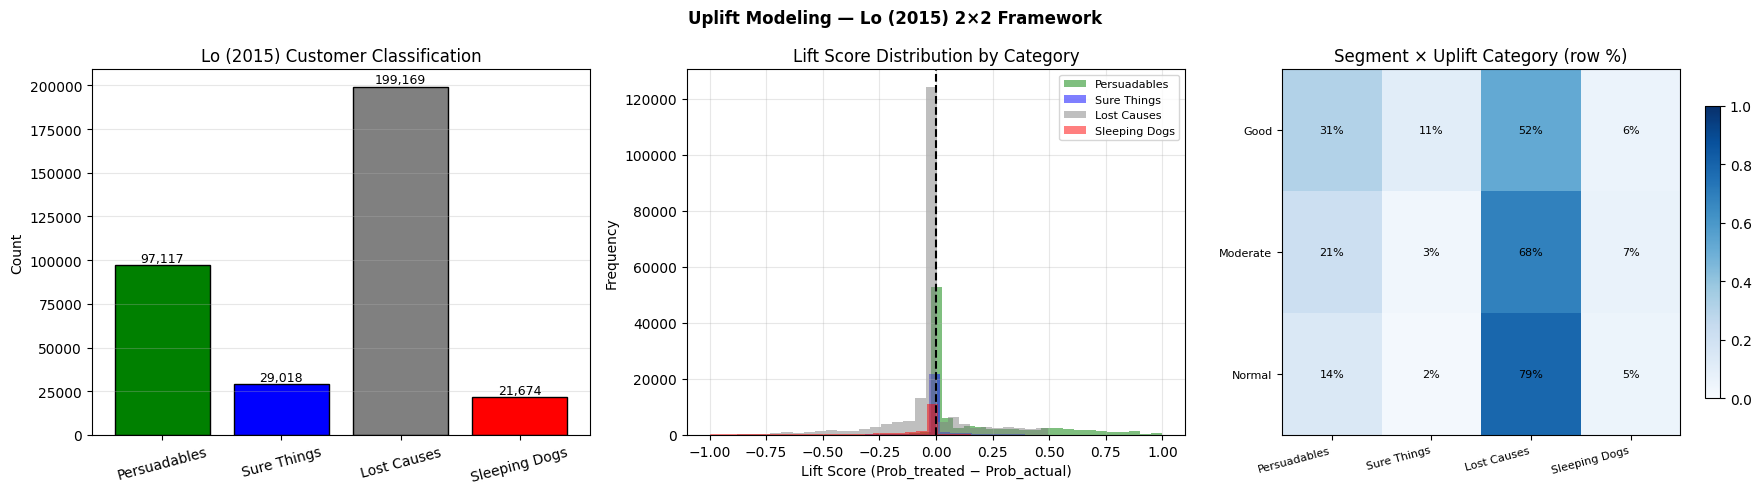

[Saved] uplift_classification.png


In [9]:
# =============================================================================
# CELL 7: UPLIFT MODELING — Lo (2015) 2×2 Framework  (New approach only)
# =============================================================================

print("\n" + "=" * 70)
print("CELL 7: UPLIFT MODELING — Lo (2015)")
print("Simulated treatment: Recency → r_25 percentile")
print("=" * 70)

uplift_results = []
colors_uplift  = {
    "Persuadables" : "green",
    "Sure Things"  : "blue",
    "Lost Causes"  : "gray",
    "Sleeping Dogs": "red"
}
cats_uplift = ["Persuadables","Sure Things","Lost Causes","Sleeping Dogs"]

for group_id, model_df in new_test_data.items():
    best_name, best_clf, feat_cols = new_best_models[group_id]

    X_actual  = model_df[feat_cols].copy()
    X_treated = X_actual.copy()
    r_25      = X_actual["Recency"].quantile(0.25)
    X_treated["Recency"] = X_treated["Recency"].clip(upper=r_25)

    prob_actual  = best_clf.predict_proba(X_actual)[:,  1]
    prob_treated = best_clf.predict_proba(X_treated)[:, 1]
    lift         = prob_treated - prob_actual

    actual_purchase   = model_df["Purchased"].values
    predicted_treated = (prob_treated >= 0.5).astype(int)

    conditions = []
    for ap, pt in zip(actual_purchase, predicted_treated):
        if   ap==1 and pt==1: conditions.append("Sure Things")
        elif ap==0 and pt==1: conditions.append("Persuadables")
        elif ap==0 and pt==0: conditions.append("Lost Causes")
        else:                 conditions.append("Sleeping Dogs")

    tmp                     = model_df.copy()
    tmp["Uplift_Category"]  = conditions
    tmp["Lift_Score"]       = lift
    tmp["Prob_Actual"]      = prob_actual
    tmp["Prob_Treated"]     = prob_treated
    tmp["ProductGroup"]     = group_id
    uplift_results.append(tmp)

uplift_all  = pd.concat(uplift_results, ignore_index=True)
cat_summary = uplift_all["Uplift_Category"].value_counts()
cat_pct     = uplift_all["Uplift_Category"].value_counts(normalize=True)

print(f"\n{'Category':<15} {'Count':>8} {'Pct':>7} {'Avg Lift':>10}")
print("─" * 44)
for cat in cats_uplift:
    if cat in cat_summary.index:
        avg_lift = (uplift_all[uplift_all["Uplift_Category"]==cat]
                    ["Lift_Score"].mean())
        print(f"  {cat:<15} {cat_summary[cat]:>8,} "
              f"{cat_pct[cat]:>7.1%} {avg_lift:>+10.4f}")

# Segment × Uplift crosstab
cross_tab = pd.crosstab(
    uplift_all["Segment"],
    uplift_all["Uplift_Category"]
)[[ c for c in cats_uplift
    if c in uplift_all["Uplift_Category"].unique()]]

print("\n--- Segment × Uplift Category (row %) ---")
print(cross_tab.div(cross_tab.sum(axis=1), axis=0)
      .map(lambda x: f"{x:.1%}").to_string())

# Persuadables deep-dive
persuadables = uplift_all[uplift_all["Uplift_Category"]=="Persuadables"]
if len(persuadables) > 0:
    print(f"\n--- Persuadables ---")
    print(f"  Count             : {len(persuadables):,}")
    print(f"  Avg Lift          : +{persuadables['Lift_Score'].mean():.4f}")
    print(f"  Avg Prob (actual) : {persuadables['Prob_Actual'].mean():.4f}")
    print(f"  Avg Prob (treated): {persuadables['Prob_Treated'].mean():.4f}")
    print(f"  Segment breakdown :")
    for seg, cnt in persuadables["Segment"].value_counts().items():
        print(f"    {seg:<12}: {cnt:>6,} ({cnt/len(persuadables):.1%})")

uplift_summary = (
    uplift_all.groupby(["Segment","Uplift_Category"])
    .agg(Count    =("Lift_Score","count"),
         Avg_Lift =("Lift_Score","mean"),
         Avg_Prob_A=("Prob_Actual","mean"),
         Avg_Prob_T=("Prob_Treated","mean"))
    .reset_index()
)
uplift_summary.to_csv(f"{OUT_DIR}/uplift_classification.csv", index=False)
print(f"\n[Saved] uplift_classification.csv")

# ── Uplift plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax   = axes[0]
vals = [cat_summary.get(c, 0) for c in cats_uplift]
cols = [colors_uplift[c] for c in cats_uplift]
bars = ax.bar(cats_uplift, vals, color=cols, edgecolor="black")
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(vals)*0.01,
            f"{val:,}", ha="center", fontsize=9)
ax.set_title("Lo (2015) Customer Classification")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=15)
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
for cat in cats_uplift:
    data = uplift_all[
        uplift_all["Uplift_Category"]==cat]["Lift_Score"]
    if len(data) > 0:
        ax.hist(data, bins=30, alpha=0.5,
                label=cat, color=colors_uplift[cat])
ax.axvline(x=0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Lift Score (Prob_treated − Prob_actual)")
ax.set_ylabel("Frequency")
ax.set_title("Lift Score Distribution by Category")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax        = axes[2]
cross_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0)
im        = ax.imshow(cross_pct.values, cmap="Blues",
                      vmin=0, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(cross_pct.columns)))
ax.set_xticklabels(cross_pct.columns, rotation=15,
                   ha="right", fontsize=8)
ax.set_yticks(np.arange(len(cross_pct.index)))
ax.set_yticklabels(cross_pct.index, fontsize=8)
for i in range(len(cross_pct.index)):
    for j in range(len(cross_pct.columns)):
        ax.text(j, i, f"{cross_pct.iloc[i,j]:.0%}",
                ha="center", va="center", fontsize=8)
ax.set_title("Segment × Uplift Category (row %)")
plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Uplift Modeling — Lo (2015) 2×2 Framework",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/uplift_classification.png", dpi=150)
plt.show()
print("[Saved] uplift_classification.png")



In [10]:
# =============================================================================
# CELL 8: TABLE OUTPUTS
#   8A — Table I   : Forecasting accuracy (paper + new)
#   8B — Table III : Cluster description  (paper + new)
#   8C — Table IV  : Risk assessment matrix (paper + new)
#   8D — Table V   : Prescriptive analytics (paper 3-var + new 5-var)
# =============================================================================

print("\n" + "=" * 70)
print("CELL 8A: TABLE I — FORECASTING ACCURACY")
print("=" * 70)

# ── Paper: Accuracy only ──────────────────────────────────────────────────
print("\n--- Table I (Paper): Accuracy per product ---")
table_i_paper = pd.DataFrame({
    prod: {
        "ANN": m["ANN"]["mean"]["accuracy"],
        "DT" : m["DecisionTree"]["mean"]["accuracy"],
        "GBT": m["GBT"]["mean"]["accuracy"]
    }
    for prod, m in paper_results.items()
}).T[["ANN","DT","GBT"]]
table_i_paper.index.name = "Product"

print(table_i_paper.map(lambda x: f"{x:.2%}").to_string())
avg_p = table_i_paper.mean()
print(f"\nAverage: ANN={avg_p['ANN']:.2%}  "
      f"DT={avg_p['DT']:.2%}  GBT={avg_p['GBT']:.2%}")
print(f"Best   : {avg_p.idxmax()} ({avg_p.max():.2%})")

table_i_paper.to_csv(f"{OUT_DIR}/table_I_paper.csv")

# ── New: Acc + F1 + AUC + MCC ────────────────────────────────────────────
print("\n--- Table I (New): Extended metrics per group ---")
rows_new = []
for gid, gm in new_results.items():
    row = {"ProductGroup": f"Group_{gid}"}
    for model, col in [("ANN","ANN"),
                        ("DecisionTree","DT"),
                        ("GBT","GBT")]:
        if model in gm:
            for metric in ["accuracy","f1","auc","mcc"]:
                row[f"{col}_{metric.capitalize()}"] = \
                    round(gm[model]["mean"][metric], 4)
    rows_new.append(row)

table_i_new = (pd.DataFrame(rows_new)
               .set_index("ProductGroup"))
print(table_i_new.to_string())

table_i_new.to_csv(f"{OUT_DIR}/table_I_new.csv")
print(f"\n[Saved] table_I_paper.csv, table_I_new.csv")

# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CELL 8B: TABLE III — CLUSTER DESCRIPTION")
print("=" * 70)

print("\n--- Table III (Paper): per product, k=3 ---")
for prod in paper_products:
    if prod not in paper_segments:
        continue
    seg_df  = paper_segments[prod]
    summary = (seg_df.groupby("Segment")
               [["Recency","Frequency","Monetary","Quantity"]]
               .mean().round(2))
    summary["Count"] = seg_df.groupby("Segment").size()
    print(f"\n  {prod}:")
    print(summary.reindex(SEG_ORDER_PAPER).to_string())

print("\n--- Table III (New): global, optimal k ---")
table_iii_new = (
    rfm.groupby("Segment")
    [["Recency","Frequency","Monetary","TotalQty"]]
    .agg(["mean","median","std"])
    .round(2)
)
table_iii_new.columns = [
    f"{c}_{s}" for c, s in table_iii_new.columns]
table_iii_new["Count"] = rfm["Segment"].value_counts()
print(table_iii_new.reindex(labels_list).to_string())

table_iii_new.to_csv(f"{OUT_DIR}/table_III_new.csv")
print(f"\n[Saved] table_III_new.csv")

# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CELL 8C: TABLE IV — RISK ASSESSMENT MATRIX")
print("=" * 70)

# ── Paper ─────────────────────────────────────────────────────────────────
risk_rows_paper = []
for prod in paper_products:
    if prod not in paper_test_data:
        continue
    tdf = paper_test_data[prod]
    for seg in SEG_ORDER_PAPER:
        sd = tdf[tdf["Segment"] == seg]
        risk_rows_paper.append({
            "Product": prod, "Segment": seg,
            "Risk": round(1 - sd["Pred_Prob"].mean(), 4)
            if len(sd) > 0 else np.nan
        })

risk_pivot_paper = pd.DataFrame(risk_rows_paper).pivot_table(
    index="Product", columns="Segment", values="Risk"
)[SEG_ORDER_PAPER]

print("\n--- Table IV (Paper) ---")
print(risk_pivot_paper.map(
    lambda x: f"{x:.2%}" if not pd.isna(x) else "N/A"
).to_string())
risk_pivot_paper.to_csv(f"{OUT_DIR}/table_IV_paper.csv")

# ── New ───────────────────────────────────────────────────────────────────
risk_rows_new = []
for gid, tdf in new_test_data.items():
    for seg in labels_list:
        sd = tdf[tdf["Segment"] == seg]
        risk_rows_new.append({
            "ProductGroup": f"Group_{gid}", "Segment": seg,
            "Risk": round(1 - sd["Pred_Prob"].mean(), 4)
            if len(sd) > 0 else np.nan
        })

risk_pivot_new = pd.DataFrame(risk_rows_new).pivot_table(
    index="ProductGroup", columns="Segment", values="Risk"
)
cols_ord       = [c for c in
                  ["Good","Moderate","Normal","Premium","At-Risk"]
                  if c in risk_pivot_new.columns]
risk_pivot_new = risk_pivot_new[cols_ord]

print("\n--- Table IV (New) ---")
print(risk_pivot_new.map(
    lambda x: f"{x:.2%}" if not pd.isna(x) else "N/A"
).to_string())
risk_pivot_new.to_csv(f"{OUT_DIR}/table_IV_new.csv")
print(f"\n[Saved] table_IV_paper.csv, table_IV_new.csv")

# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CELL 8D: TABLE V — PRESCRIPTIVE ANALYTICS")
print("Paper: 3-var DE  |  New: 5-var DE")
print("=" * 70)

de_eval        = []
presc_paper    = []
presc_new      = []

for group_id in new_test_data.keys():
    opt_df = new_test_data[group_id].dropna(
        subset=["Pred_Prob","Recency","Frequency",
                "Monetary","Segment","Region"]
    ).copy()

    if len(opt_df) < 10:
        continue

    prod_regions = [r for r in REGION_ORDER
                    if r in opt_df["Region"].values]
    if not prod_regions:
        continue

    bounds_3 = [
        (float(opt_df["Recency"].min()),
         float(opt_df["Recency"].max())),
        (float(opt_df["Frequency"].min()),
         float(opt_df["Frequency"].max())),
        (float(opt_df["Monetary"].min()),
         float(opt_df["Monetary"].max())),
        (0, max(1, len(SEG_ORDER_NEW)-1))
    ]
    bounds_5 = bounds_3 + [(0, max(1, len(prod_regions)-1))]

    if any(lo == hi for lo, hi in bounds_3[:3]):
        continue

    try:
        t0   = time.time()
        res3 = differential_evolution(
            make_de_objective(opt_df, SEG_ORDER_NEW, None),
            bounds_3, **DE_KWARGS)
        time_3 = time.time() - t0

        t0   = time.time()
        res5 = differential_evolution(
            make_de_objective(opt_df, SEG_ORDER_NEW, prod_regions),
            bounds_5, **DE_KWARGS)
        time_5 = time.time() - t0

        # 3-var solution
        seg3  = SEG_ORDER_NEW[
            int(round(res3.x[3])) % len(SEG_ORDER_NEW)]
        sel3  = opt_df[
            (opt_df["Recency"]   <= res3.x[0]) &
            (opt_df["Frequency"] >= res3.x[1]) &
            (opt_df["Monetary"]  >= res3.x[2]) &
            (opt_df["Segment"]   == seg3)]
        conf3  = sel3["Pred_Prob"].mean() if len(sel3) >= 5 else 0.0
        score3 = conf3 * np.sqrt(len(sel3)) if len(sel3) >= 5 else 0.0

        # 5-var solution
        seg5  = SEG_ORDER_NEW[
            int(round(res5.x[3])) % len(SEG_ORDER_NEW)]
        reg5  = prod_regions[
            int(round(res5.x[4])) % len(prod_regions)]
        sel5  = opt_df[
            (opt_df["Recency"]   <= res5.x[0]) &
            (opt_df["Frequency"] >= res5.x[1]) &
            (opt_df["Monetary"]  >= res5.x[2]) &
            (opt_df["Segment"]   == seg5)       &
            (opt_df["Region"]    == reg5)]
        conf5  = sel5["Pred_Prob"].mean() if len(sel5) >= 5 else 0.0
        score5 = conf5 * np.sqrt(len(sel5)) if len(sel5) >= 5 else 0.0

        grp_rev = pareto_products[
            pareto_products["ProductGroup"] == group_id
        ]["Total_Revenue"].sum()

        de_eval.append({
            "Group"      : f"Group_{group_id}",
            "Conf_3var"  : round(conf3,  4),
            "N_3var"     : len(sel3),
            "Score_3var" : round(score3, 4),
            "Seg_3var"   : seg3,
            "Time_3var"  : round(time_3, 2),
            "Conf_5var"  : round(conf5,  4),
            "N_5var"     : len(sel5),
            "Score_5var" : round(score5, 4),
            "Seg_5var"   : seg5,
            "Reg_5var"   : reg5,
            "Time_5var"  : round(time_5, 2),
            "Delta_Conf" : round(conf5  - conf3,  4),
            "Delta_Score": round(score5 - score3, 4),
            "Delta_N"    : len(sel5) - len(sel3),
        })

        presc_paper.append({
            "Group"             : f"Group_{group_id}",
            "Revenue"           : round(grp_rev, 2),
            "Confidence"        : round(conf3, 3),
            "Customer_Type"     : seg3,
            "Recency_Max"       : round(res3.x[0], 1),
            "Frequency_Min"     : round(res3.x[1], 1),
            "Monetary_Min"      : round(res3.x[2], 2),
            "N_Customers"       : len(sel3),
            "Obj_Score"         : round(score3, 4),
        })

        presc_new.append({
            "Group"             : f"Group_{group_id}",
            "Revenue"           : round(grp_rev, 2),
            "Confidence"        : round(conf5, 3),
            "Customer_Region"   : reg5,
            "Customer_Type"     : seg5,
            "Recency_Max"       : round(res5.x[0], 1),
            "Frequency_Min"     : round(res5.x[1], 1),
            "Monetary_Min"      : round(res5.x[2], 2),
            "N_Customers"       : len(sel5),
            "Obj_Score"         : round(score5, 4),
        })

        print(f"  Group_{group_id}:")
        print(f"    3-var: Conf={conf3:.4f} N={len(sel3):>4} "
              f"Score={score3:.4f} Seg={seg3}")
        print(f"    5-var: Conf={conf5:.4f} N={len(sel5):>4} "
              f"Score={score5:.4f} Seg={seg5} Reg={reg5}")
        print(f"    Delta: ΔConf={conf5-conf3:+.4f} "
              f"ΔScore={score5-score3:+.4f} "
              f"ΔN={len(sel5)-len(sel3):+d}")

    except Exception as e:
        print(f"  Group_{group_id}: FAILED — {str(e)[:60]}")

de_eval_df  = pd.DataFrame(de_eval)
table_v_paper = (pd.DataFrame(presc_paper)
                 .set_index("Group")
                 .sort_values("Revenue", ascending=False))
table_v_new   = (pd.DataFrame(presc_new)
                 .set_index("Group")
                 .sort_values("Revenue", ascending=False))

print(f"\n--- Table V (Paper: 3-var DE) ---")
print(table_v_paper.to_string())

print(f"\n--- Table V (New: 5-var DE) ---")
print(table_v_new.to_string())

if not de_eval_df.empty:
    print(f"\n--- DE Comparison Summary ---")
    print(f"  Avg Conf  — 3-var: {de_eval_df['Conf_3var'].mean():.4f}  "
          f"5-var: {de_eval_df['Conf_5var'].mean():.4f}  "
          f"Δ: {de_eval_df['Delta_Conf'].mean():+.4f}")
    print(f"  Avg Score — 3-var: {de_eval_df['Score_3var'].mean():.4f}  "
          f"5-var: {de_eval_df['Score_5var'].mean():.4f}  "
          f"Δ: {de_eval_df['Delta_Score'].mean():+.4f}")
    print(f"  Avg N     — 3-var: {de_eval_df['N_3var'].mean():.1f}  "
          f"5-var: {de_eval_df['N_5var'].mean():.1f}  "
          f"Δ: {de_eval_df['Delta_N'].mean():+.1f}")

    if len(de_eval_df) > 1:
        t_stat, p_val = stats.ttest_rel(
            de_eval_df["Score_5var"],
            de_eval_df["Score_3var"]
        )
        print(f"\n  Paired t-test (Score_5var vs Score_3var):")
        print(f"    t={t_stat:.4f}  p={p_val:.4f}  "
              f"{'✓ p<0.05' if p_val < 0.05 else '✗ n.s.'}")

table_v_paper.to_csv(f"{OUT_DIR}/table_V_paper.csv")
table_v_new.to_csv(f"{OUT_DIR}/table_V_new.csv")
de_eval_df.to_csv(f"{OUT_DIR}/eval_de_comparison.csv", index=False)
print(f"\n[Saved] table_V_paper.csv, table_V_new.csv, "
      f"eval_de_comparison.csv")



CELL 8A: TABLE I — FORECASTING ACCURACY

--- Table I (Paper): Accuracy per product ---
            ANN      DT     GBT
Product                        
85123A   70.33%  73.88%  72.75%
22423    68.37%  71.74%  70.61%
85099B   71.45%  74.63%  73.71%
84879    67.83%  71.88%  70.27%
20725    70.33%  73.20%  72.21%
21212    67.96%  72.07%  70.49%
47566    66.75%  71.38%  70.26%
22383    69.96%  74.35%  72.84%
20727    69.59%  72.63%  71.89%

Average: ANN=69.18%  DT=72.86%  GBT=71.67%
Best   : DT (72.86%)

--- Table I (New): Extended metrics per group ---
              ANN_Accuracy  ANN_F1  ANN_Auc  ANN_Mcc  DT_Accuracy   DT_F1  DT_Auc  DT_Mcc  GBT_Accuracy  GBT_F1  GBT_Auc  GBT_Mcc
ProductGroup                                                                                                                     
Group_0             0.5503  0.5112   0.5739   0.1128       0.6413  0.6183  0.7078  0.2847        0.6095  0.5389   0.6611   0.2300
Group_1             0.5845  0.5619   0.6138   0.1738  


CELL 9: CV METHOD COMPARISON
StratifiedKFold (Paper) vs TimeSeriesSplit (New)
Data: Group_1 | Balanced: 454,056 samples

Model           CV                        Acc       F1      AUC      MCC
─────────────────────────────────────────────────────────────────
  DecisionTree    StratifiedKFold        0.6733   0.6525   0.7499   0.3492
  DecisionTree    TimeSeriesSplit        0.6548   0.6313   0.7217   0.3121

  ANN             StratifiedKFold        0.5837   0.5564   0.6179   0.1763
  ANN             TimeSeriesSplit        0.5845   0.5619   0.6138   0.1738

  GBT             StratifiedKFold        0.6209   0.5592   0.6718   0.2518
  GBT             TimeSeriesSplit        0.6196   0.5590   0.6707   0.2486


--- Paired t-test: SKF vs TSS (fold-level Accuracy) ---
Model             t-stat    p-value       Result
────────────────────────────────────────────────
  DecisionTree      2.9635     0.0159     ✓ p<0.05
  ANN              -0.1802     0.8610       ✗ n.s.
  GBT               1.3494   

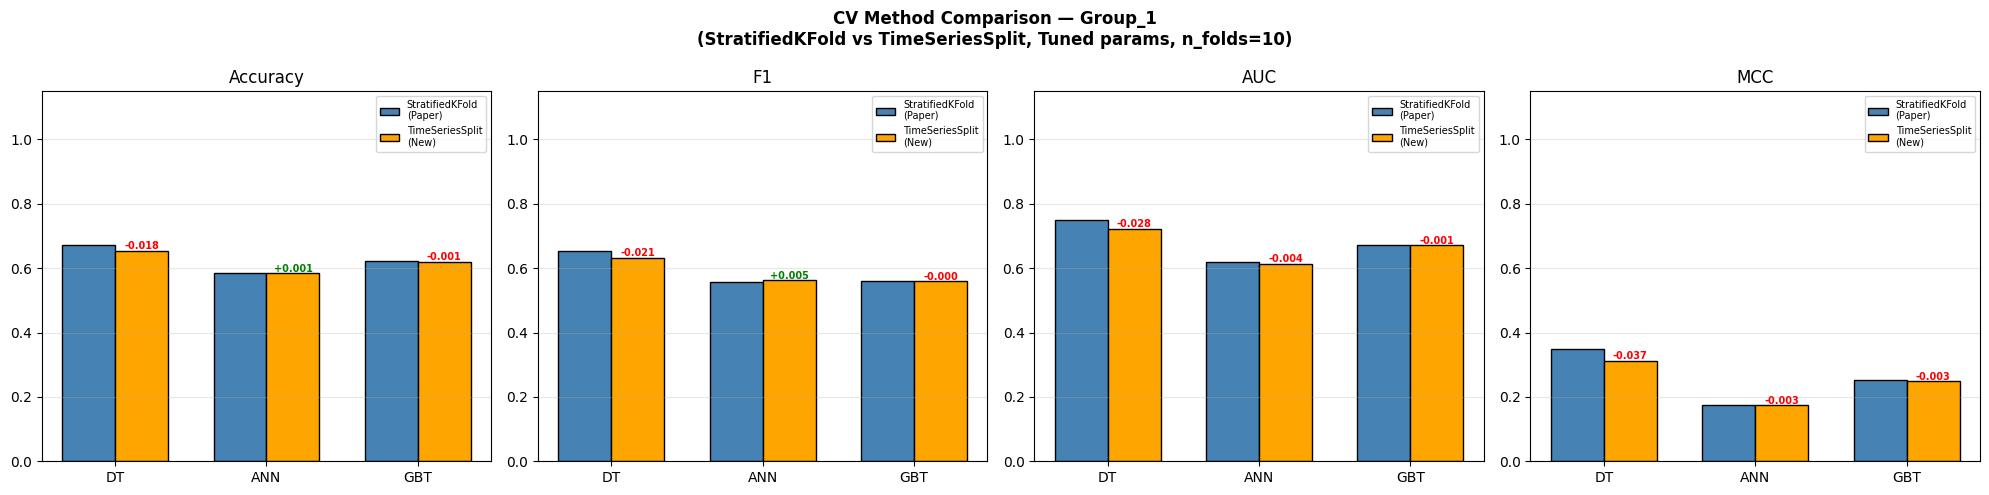

[Saved] eval_cv_comparison.png


In [11]:
# =============================================================================
# CELL 9: CV METHOD EVALUATION
# StratifiedKFold (Paper) vs TimeSeriesSplit (New) — same data, same models
# =============================================================================

print("\n" + "=" * 70)
print("CELL 9: CV METHOD COMPARISON")
print("StratifiedKFold (Paper) vs TimeSeriesSplit (New)")
print("=" * 70)

skf_cmp  = StratifiedKFold(n_splits=N_FOLDS,
                            shuffle=True, random_state=RANDOM_STATE)
tscv_cmp = TimeSeriesSplit(n_splits=N_FOLDS)

cv_comp     = []
fold_acc_skf  = {m: [] for m in ["DecisionTree","ANN","GBT"]}
fold_acc_tscv = {m: [] for m in ["DecisionTree","ANN","GBT"]}

models_cmp = build_tuned_models(best_params, RANDOM_STATE)

print(f"Data: Group_{repr_group} | "
      f"Balanced: {len(X_bal_r):,} samples\n")
print(f"{'Model':<15} {'CV':<20} "
      f"{'Acc':>8} {'F1':>8} {'AUC':>8} {'MCC':>8}")
print("─" * 65)

for name, clf in models_cmp.items():
    # StratifiedKFold
    res_skf = run_cv(clf, X_bal_r, y_bal_r,
                     skf_cmp, is_stratified=True)
    cv_comp.append({
        "Model": name, "CV": "StratifiedKFold",
        **{k: round(v, 4)
           for k, v in res_skf["mean"].items()}
    })
    print(f"  {name:<15} {'StratifiedKFold':<20} "
          f"{res_skf['mean']['accuracy']:>8.4f} "
          f"{res_skf['mean']['f1']:>8.4f} "
          f"{res_skf['mean']['auc']:>8.4f} "
          f"{res_skf['mean']['mcc']:>8.4f}")

    # TimeSeriesSplit
    res_tss = run_cv(clf, X_bal_r, y_bal_r,
                     tscv_cmp, is_stratified=False)
    cv_comp.append({
        "Model": name, "CV": "TimeSeriesSplit",
        **{k: round(v, 4)
           for k, v in res_tss["mean"].items()}
    })
    print(f"  {name:<15} {'TimeSeriesSplit':<20} "
          f"{res_tss['mean']['accuracy']:>8.4f} "
          f"{res_tss['mean']['f1']:>8.4f} "
          f"{res_tss['mean']['auc']:>8.4f} "
          f"{res_tss['mean']['mcc']:>8.4f}")

    # Collect fold-level for t-test
    for tr, val in skf_cmp.split(X_bal_r, y_bal_r):
        clf.fit(X_bal_r.iloc[tr], y_bal_r.iloc[tr])
        fold_acc_skf[name].append(
            accuracy_score(y_bal_r.iloc[val],
                           clf.predict(X_bal_r.iloc[val])))
    for tr, val in tscv_cmp.split(X_bal_r):
        clf.fit(X_bal_r.iloc[tr], y_bal_r.iloc[tr])
        fold_acc_tscv[name].append(
            accuracy_score(y_bal_r.iloc[val],
                           clf.predict(X_bal_r.iloc[val])))
    print()

cv_comp_df = pd.DataFrame(cv_comp)

# ── Paired t-test ─────────────────────────────────────────────────────────
print(f"\n--- Paired t-test: SKF vs TSS (fold-level Accuracy) ---")
print(f"{'Model':<15} {'t-stat':>8} {'p-value':>10} {'Result':>12}")
print("─" * 48)

for name in ["DecisionTree","ANN","GBT"]:
    n_min = min(len(fold_acc_skf[name]),
                len(fold_acc_tscv[name]))
    t_s, p_v = stats.ttest_rel(
        fold_acc_skf[name][:n_min],
        fold_acc_tscv[name][:n_min]
    )
    result = "✓ p<0.05" if p_v < 0.05 else "✗ n.s."
    print(f"  {name:<15} {t_s:>8.4f} {p_v:>10.4f} {result:>12}")

cv_comp_df.to_csv(f"{OUT_DIR}/eval_cv_comparison.csv", index=False)
print(f"\n[Saved] eval_cv_comparison.csv")

# ── Visualization ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics_cv = ["accuracy","f1","auc","mcc"]
labels_cv  = ["Accuracy","F1","AUC","MCC"]
x_cv       = np.arange(3)
width_cv   = 0.35

for ax, metric, label in zip(axes, metrics_cv, labels_cv):
    skf_vals = [cv_comp_df[
        (cv_comp_df["Model"]==m) &
        (cv_comp_df["CV"]=="StratifiedKFold")
    ][metric].values[0] for m in ["DecisionTree","ANN","GBT"]]

    tss_vals = [cv_comp_df[
        (cv_comp_df["Model"]==m) &
        (cv_comp_df["CV"]=="TimeSeriesSplit")
    ][metric].values[0] for m in ["DecisionTree","ANN","GBT"]]

    ax.bar(x_cv - width_cv/2, skf_vals, width_cv,
           label="StratifiedKFold\n(Paper)",
           color="steelblue", edgecolor="black")
    ax.bar(x_cv + width_cv/2, tss_vals, width_cv,
           label="TimeSeriesSplit\n(New)",
           color="orange", edgecolor="black")

    for i, (sv, tv) in enumerate(zip(skf_vals, tss_vals)):
        delta = tv - sv
        color = "green" if delta > 0 else "red"
        ax.text(i + width_cv/2, tv + 0.005,
                f"{delta:+.3f}", ha="center",
                fontsize=7, color=color, fontweight="bold")

    ax.set_xticks(x_cv)
    ax.set_xticklabels(["DT","ANN","GBT"])
    ax.set_ylim(0, 1.15)
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"CV Method Comparison — Group_{repr_group}\n"
    f"(StratifiedKFold vs TimeSeriesSplit, "
    f"Tuned params, n_folds={N_FOLDS})",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eval_cv_comparison.png", dpi=150)
plt.show()
print("[Saved] eval_cv_comparison.png")



CELL 10: COMPREHENSIVE DASHBOARD


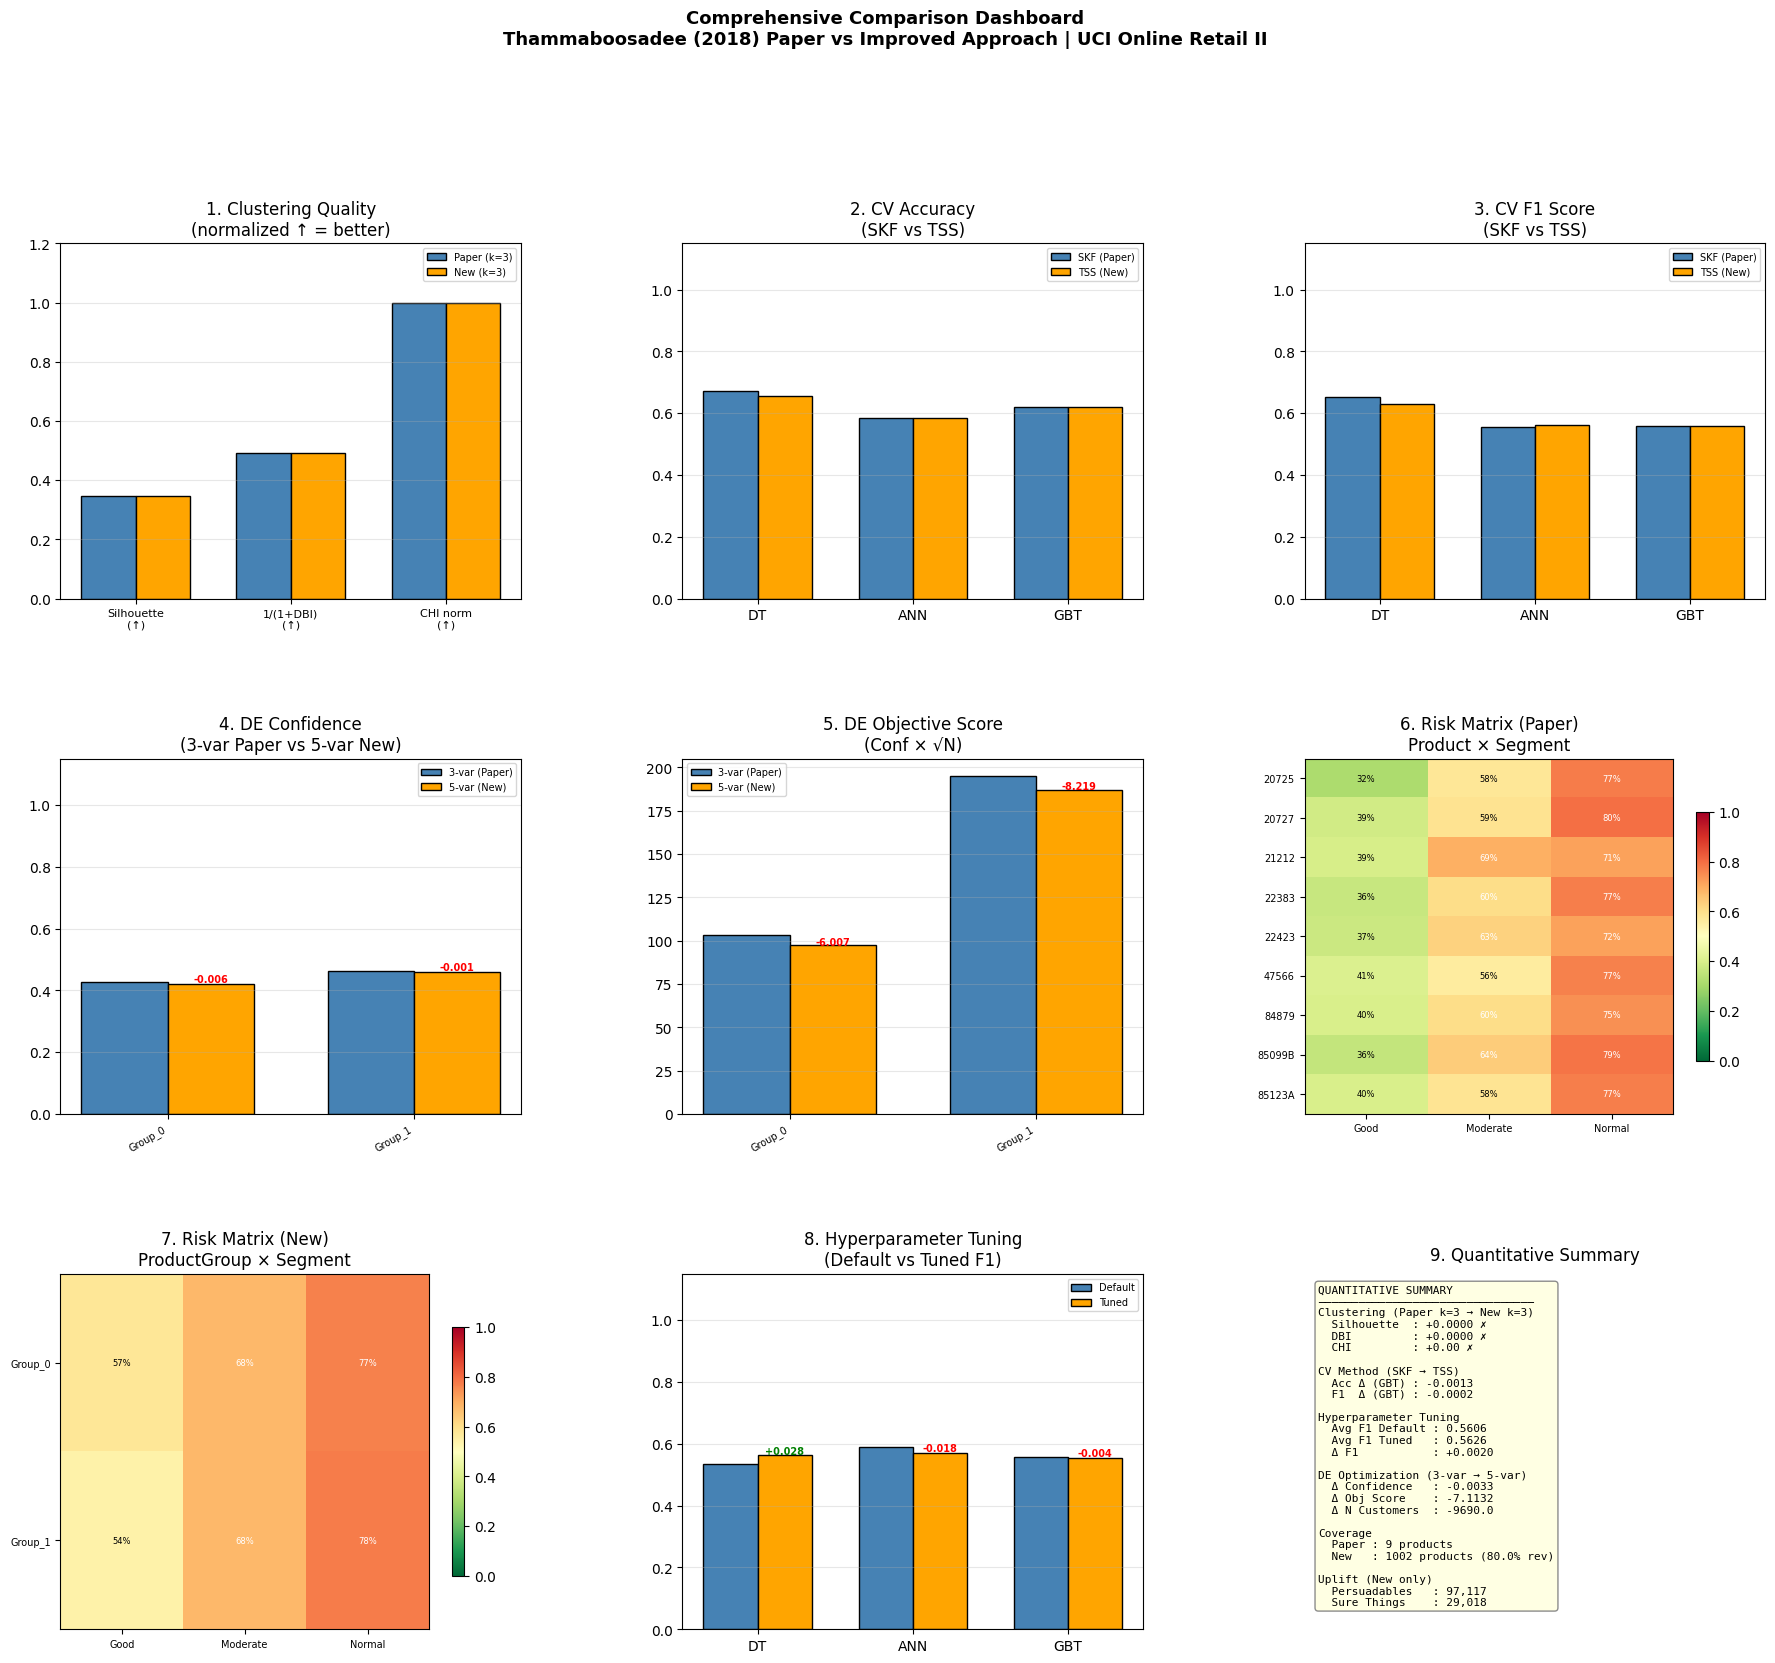

[Saved] comparison_dashboard.png


In [12]:
# =============================================================================
# CELL 10: COMPREHENSIVE COMPARISON DASHBOARD (9 panels)
# =============================================================================

print("\n" + "=" * 70)
print("CELL 10: COMPREHENSIVE DASHBOARD")
print("=" * 70)

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig,
                        hspace=0.45, wspace=0.35)

# ── Panel 1: Clustering Quality ───────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
norm_vals = [
    [sil_k3,
     1/(1+dbi_k3),
     chi_k3/max(chi_k3, chi_optk)],
    [sil_optk,
     1/(1+dbi_optk),
     chi_optk/max(chi_k3, chi_optk)]
]
x_c = np.arange(3)
w_c = 0.35
for i, (label, vals, color) in enumerate(zip(
    ["Paper (k=3)", f"New (k={optimal_k})"],
    norm_vals,
    ["steelblue","orange"]
)):
    ax.bar(x_c + i*w_c, vals, w_c,
           label=label, color=color, edgecolor="black")
ax.set_xticks(x_c + w_c/2)
ax.set_xticklabels(["Silhouette\n(↑)",
                    "1/(1+DBI)\n(↑)",
                    "CHI norm\n(↑)"], fontsize=8)
ax.set_ylim(0, 1.2)
ax.set_title("1. Clustering Quality\n(normalized ↑ = better)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis="y")

# ── Panel 2: CV Accuracy ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
x_m = np.arange(3); w_m = 0.35
skf_acc = [cv_comp_df[
    (cv_comp_df["Model"]==m) &
    (cv_comp_df["CV"]=="StratifiedKFold")
]["accuracy"].values[0]
for m in ["DecisionTree","ANN","GBT"]]
tss_acc = [cv_comp_df[
    (cv_comp_df["Model"]==m) &
    (cv_comp_df["CV"]=="TimeSeriesSplit")
]["accuracy"].values[0]
for m in ["DecisionTree","ANN","GBT"]]
ax.bar(x_m - w_m/2, skf_acc, w_m,
       label="SKF (Paper)", color="steelblue", edgecolor="black")
ax.bar(x_m + w_m/2, tss_acc, w_m,
       label="TSS (New)",   color="orange",    edgecolor="black")
ax.set_xticks(x_m)
ax.set_xticklabels(["DT","ANN","GBT"])
ax.set_ylim(0, 1.15)
ax.set_title("2. CV Accuracy\n(SKF vs TSS)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis="y")

# ── Panel 3: CV F1 ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
skf_f1 = [cv_comp_df[
    (cv_comp_df["Model"]==m) &
    (cv_comp_df["CV"]=="StratifiedKFold")
]["f1"].values[0]
for m in ["DecisionTree","ANN","GBT"]]
tss_f1 = [cv_comp_df[
    (cv_comp_df["Model"]==m) &
    (cv_comp_df["CV"]=="TimeSeriesSplit")
]["f1"].values[0]
for m in ["DecisionTree","ANN","GBT"]]
ax.bar(x_m - w_m/2, skf_f1, w_m,
       label="SKF (Paper)", color="steelblue", edgecolor="black")
ax.bar(x_m + w_m/2, tss_f1, w_m,
       label="TSS (New)",   color="orange",    edgecolor="black")
ax.set_xticks(x_m)
ax.set_xticklabels(["DT","ANN","GBT"])
ax.set_ylim(0, 1.15)
ax.set_title("3. CV F1 Score\n(SKF vs TSS)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis="y")

# ── Panel 4: DE Confidence ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
if not de_eval_df.empty:
    x_de = np.arange(len(de_eval_df)); w_de = 0.35
    ax.bar(x_de - w_de/2, de_eval_df["Conf_3var"], w_de,
           label="3-var (Paper)", color="steelblue", edgecolor="black")
    ax.bar(x_de + w_de/2, de_eval_df["Conf_5var"], w_de,
           label="5-var (New)",   color="orange",    edgecolor="black")
    for i, (c3, c5) in enumerate(
        zip(de_eval_df["Conf_3var"], de_eval_df["Conf_5var"])
    ):
        delta = c5 - c3
        color = "green" if delta > 0 else "red"
        ax.text(i + w_de/2, c5 + 0.005,
                f"{delta:+.3f}", ha="center",
                fontsize=7, color=color, fontweight="bold")
    ax.set_xticks(x_de)
    ax.set_xticklabels(de_eval_df["Group"],
                       rotation=30, ha="right", fontsize=7)
    ax.set_ylim(0, 1.15)
    ax.set_title("4. DE Confidence\n(3-var Paper vs 5-var New)")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis="y")

# ── Panel 5: DE Objective Score ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
if not de_eval_df.empty:
    ax.bar(x_de - w_de/2, de_eval_df["Score_3var"], w_de,
           label="3-var (Paper)", color="steelblue", edgecolor="black")
    ax.bar(x_de + w_de/2, de_eval_df["Score_5var"], w_de,
           label="5-var (New)",   color="orange",    edgecolor="black")
    for i, (s3, s5) in enumerate(
        zip(de_eval_df["Score_3var"], de_eval_df["Score_5var"])
    ):
        delta = s5 - s3
        color = "green" if delta > 0 else "red"
        ax.text(i + w_de/2, s5 + 0.005,
                f"{delta:+.3f}", ha="center",
                fontsize=7, color=color, fontweight="bold")
    ax.set_xticks(x_de)
    ax.set_xticklabels(de_eval_df["Group"],
                       rotation=30, ha="right", fontsize=7)
    ax.set_title("5. DE Objective Score\n(Conf × √N)")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis="y")

# ── Panel 6: Risk Heatmap — Paper ────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
if not risk_pivot_paper.empty:
    im = ax.imshow(risk_pivot_paper.values,
                   cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(risk_pivot_paper.shape[1]))
    ax.set_xticklabels(risk_pivot_paper.columns, fontsize=7)
    ax.set_yticks(np.arange(len(risk_pivot_paper)))
    ax.set_yticklabels(risk_pivot_paper.index, fontsize=7)
    for i in range(len(risk_pivot_paper)):
        for j in range(risk_pivot_paper.shape[1]):
            val = risk_pivot_paper.iloc[i, j]
            if not np.isnan(val):
                clr = "white" if val > 0.6 else "black"
                ax.text(j, i, f"{val:.0%}",
                        ha="center", va="center",
                        fontsize=6, color=clr)
    ax.set_title("6. Risk Matrix (Paper)\nProduct × Segment")
    plt.colorbar(im, ax=ax, shrink=0.7)

# ── Panel 7: Risk Heatmap — New ──────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
if not risk_pivot_new.empty:
    im = ax.imshow(risk_pivot_new.values,
                   cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(np.arange(risk_pivot_new.shape[1]))
    ax.set_xticklabels(risk_pivot_new.columns, fontsize=7)
    ax.set_yticks(np.arange(len(risk_pivot_new)))
    ax.set_yticklabels(risk_pivot_new.index, fontsize=7)
    for i in range(len(risk_pivot_new)):
        for j in range(risk_pivot_new.shape[1]):
            val = risk_pivot_new.iloc[i, j]
            if not np.isnan(val):
                clr = "white" if val > 0.6 else "black"
                ax.text(j, i, f"{val:.0%}",
                        ha="center", va="center",
                        fontsize=6, color=clr)
    ax.set_title("7. Risk Matrix (New)\nProductGroup × Segment")
    plt.colorbar(im, ax=ax, shrink=0.7)

# ── Panel 8: Hyperparameter Default vs Tuned ─────────────────────────────
ax = fig.add_subplot(gs[2, 1])
x_hp = np.arange(3); w_hp = 0.35
def_f1 = [hp_comp_df[
    (hp_comp_df["Model"]==m) &
    (hp_comp_df["Setting"]=="Default")
]["F1"].values[0]
for m in ["DecisionTree","ANN","GBT"]]
tun_f1 = [hp_comp_df[
    (hp_comp_df["Model"]==m) &
    (hp_comp_df["Setting"]=="Tuned")
]["F1"].values[0]
for m in ["DecisionTree","ANN","GBT"]]
ax.bar(x_hp - w_hp/2, def_f1, w_hp,
       label="Default", color="steelblue", edgecolor="black")
ax.bar(x_hp + w_hp/2, tun_f1, w_hp,
       label="Tuned",   color="orange",    edgecolor="black")
for i, (dv, tv) in enumerate(zip(def_f1, tun_f1)):
    delta = tv - dv
    color = "green" if delta > 0 else "red"
    ax.text(i + w_hp/2, tv + 0.005,
            f"{delta:+.3f}", ha="center",
            fontsize=7, color=color, fontweight="bold")
ax.set_xticks(x_hp)
ax.set_xticklabels(["DT","ANN","GBT"])
ax.set_ylim(0, 1.15)
ax.set_title("8. Hyperparameter Tuning\n(Default vs Tuned F1)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, axis="y")

# ── Panel 9: Quantitative Summary Text ───────────────────────────────────
ax = fig.add_subplot(gs[2, 2])
ax.axis("off")

d_conf_str  = (f"{de_eval_df['Delta_Conf'].mean():+.4f}"
               if not de_eval_df.empty else "N/A")
d_score_str = (f"{de_eval_df['Delta_Score'].mean():+.4f}"
               if not de_eval_df.empty else "N/A")
d_n_str     = (f"{de_eval_df['Delta_N'].mean():+.1f}"
               if not de_eval_df.empty else "N/A")
avg_tun_f1  = np.mean(tun_f1)
avg_def_f1  = np.mean(def_f1)

summary_text = (
    f"QUANTITATIVE SUMMARY\n"
    f"{'─'*32}\n"
    f"Clustering (Paper k=3 → New k={optimal_k})\n"
    f"  Silhouette  : {d_sil:+.4f} "
    f"{'✓' if d_sil > 0 else '✗'}\n"
    f"  DBI         : {d_dbi:+.4f} "
    f"{'✓' if d_dbi < 0 else '✗'}\n"
    f"  CHI         : {d_chi:+.2f} "
    f"{'✓' if d_chi > 0 else '✗'}\n\n"
    f"CV Method (SKF → TSS)\n"
    f"  Acc Δ (GBT) : "
    f"{tss_acc[2]-skf_acc[2]:+.4f}\n"
    f"  F1  Δ (GBT) : "
    f"{tss_f1[2]-skf_f1[2]:+.4f}\n\n"
    f"Hyperparameter Tuning\n"
    f"  Avg F1 Default : {avg_def_f1:.4f}\n"
    f"  Avg F1 Tuned   : {avg_tun_f1:.4f}\n"
    f"  Δ F1           : {avg_tun_f1-avg_def_f1:+.4f}\n\n"
    f"DE Optimization (3-var → 5-var)\n"
    f"  Δ Confidence   : {d_conf_str}\n"
    f"  Δ Obj Score    : {d_score_str}\n"
    f"  Δ N Customers  : {d_n_str}\n\n"
    f"Coverage\n"
    f"  Paper : {N_TOP_PRODUCTS} products\n"
    f"  New   : {n_pareto} products "
    f"({pareto_rev/total_revenue_all:.1%} rev)\n\n"
    f"Uplift (New only)\n"
    f"  Persuadables   : "
    f"{(uplift_all['Uplift_Category']=='Persuadables').sum():,}\n"
    f"  Sure Things    : "
    f"{(uplift_all['Uplift_Category']=='Sure Things').sum():,}"
)

ax.text(0.03, 0.97, summary_text,
        transform=ax.transAxes,
        fontsize=8, verticalalignment="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round",
                  facecolor="lightyellow",
                  edgecolor="gray", alpha=0.9))
ax.set_title("9. Quantitative Summary", pad=10)

plt.suptitle(
    "Comprehensive Comparison Dashboard\n"
    "Thammaboosadee (2018) Paper vs Improved Approach | "
    "UCI Online Retail II",
    fontsize=13, fontweight="bold", y=1.01
)
plt.savefig(f"{OUT_DIR}/comparison_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("[Saved] comparison_dashboard.png")



In [13]:
# =============================================================================
# CELL 11: FINAL SUMMARY TABLE + FILES LIST
# =============================================================================

print("\n" + "=" * 70)
print("CELL 11: FINAL QUANTITATIVE SUMMARY")
print("=" * 70)

summary_rows = [
    ["Product Coverage", "N products",
     str(N_TOP_PRODUCTS), str(n_pareto), "New"],
    ["Product Coverage", "Revenue %",
     f"{paper_revenue/total_revenue_all:.1%}",
     f"{pareto_rev/total_revenue_all:.1%}", "New"],
    ["Segmentation", "k value",
     "3 (fixed)", f"{optimal_k} (data-driven)", "New"],
    ["Segmentation", "Silhouette",
     f"{sil_k3:.4f}", f"{sil_optk:.4f}",
     "✓ New" if d_sil > 0 else "✓ Paper"],
    ["Segmentation", "Davies-Bouldin",
     f"{dbi_k3:.4f}", f"{dbi_optk:.4f}",
     "✓ New" if d_dbi < 0 else "✓ Paper"],
    ["Segmentation", "Calinski-Harabasz",
     f"{chi_k3:.2f}", f"{chi_optk:.2f}",
     "✓ New" if d_chi > 0 else "✓ Paper"],
    ["Validation", "CV Method",
     "StratifiedKFold", "TimeSeriesSplit", "New"],
    ["Validation", "Metrics",
     "Accuracy only", "Acc+F1+AUC+MCC", "New"],
    ["Model Selection", "Criterion",
     "Highest Accuracy", "Highest F1", "New"],
    ["Hyperparameters", "Selection",
     "Hardcoded default",
     "RandomizedSearchCV", "New"],
    ["Hyperparameters", "Avg F1",
     f"{avg_def_f1:.4f}", f"{avg_tun_f1:.4f}",
     "✓ New" if avg_tun_f1 > avg_def_f1 else "✓ Paper"],
    ["DE Optimization", "Variables",
     "3 (R,F,M+Seg)",
     "5 (R,F,M+Seg+Reg)", "New"],
    ["DE Optimization", "Avg Confidence",
     f"{de_eval_df['Conf_3var'].mean():.4f}"
     if not de_eval_df.empty else "N/A",
     f"{de_eval_df['Conf_5var'].mean():.4f}"
     if not de_eval_df.empty else "N/A",
     ("✓ New" if not de_eval_df.empty and
      de_eval_df["Delta_Conf"].mean() > 0
      else "✓ Paper")],
    ["DE Optimization", "Avg Obj Score",
     f"{de_eval_df['Score_3var'].mean():.4f}"
     if not de_eval_df.empty else "N/A",
     f"{de_eval_df['Score_5var'].mean():.4f}"
     if not de_eval_df.empty else "N/A",
     ("✓ New" if not de_eval_df.empty and
      de_eval_df["Delta_Score"].mean() > 0
      else "✓ Paper")],
    ["Uplift Modeling", "Framework",
     "Not present", "Lo (2015) 2×2", "New"],
    ["Feature Engineering", "Leakage risk",
     "Segment_Code included", "Removed", "New"],
    ["DE Implementation", "Closure safety",
     "Reference capture", "data.copy()", "New"],
]

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Dimension","Metric",
             "Paper (2018)","New Approach","Winner"]
)

print("\n" + summary_df.to_string(index=False))
summary_df.to_csv(f"{OUT_DIR}/final_comparison_summary.csv",
                  index=False)
print(f"\n[Saved] final_comparison_summary.csv")

# ── Files output list ─────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ALL OUTPUT FILES")
print("=" * 70)

files_saved = [
    # Tables
    ("table_I_paper.csv",
     "Table I  — Paper: Accuracy per product (ANN/DT/GBT)"),
    ("table_I_new.csv",
     "Table I  — New : Acc+F1+AUC+MCC per group"),
    ("table_III_new.csv",
     "Table III — New: Cluster description (mean/median/std)"),
    ("table_IV_paper.csv",
     "Table IV — Paper: Risk matrix (Product × Segment)"),
    ("table_IV_new.csv",
     "Table IV — New : Risk matrix (Group × Segment)"),
    ("table_V_paper.csv",
     "Table V  — Paper: DE 3-var prescriptive results"),
    ("table_V_new.csv",
     "Table V  — New : DE 5-var prescriptive results"),
    # Evaluations
    ("eval_clustering_comparison.csv",
     "Eval — Clustering: Silhouette/DBI/CHI (k=3 vs optimal)"),
    ("eval_cv_comparison.csv",
     "Eval — CV method: SKF vs TSS per model"),
    ("eval_de_comparison.csv",
     "Eval — DE: 3-var vs 5-var per group"),
    ("hyperparameter_tuning.csv",
     "Eval — HP tuning: Best params + F1 per model"),
    ("hyperparameter_comparison.csv",
     "Eval — HP: Default vs Tuned all metrics"),
    ("sensitivity_analysis.csv",
     "Eval — Sensitivity: F1 vs hyperparameter values"),
    ("uplift_classification.csv",
     "Eval — Uplift: Lo (2015) by Segment × Category"),
    ("final_comparison_summary.csv",
     "Summary — All dimensions Paper vs New"),
    # Plots
    ("optimal_k_selection.png",
     "Plot — Elbow + Silhouette for k selection"),
    ("sensitivity_analysis.png",
     "Plot — Sensitivity analysis (3 models)"),
    ("eval_cv_comparison.png",
     "Plot — CV method comparison (4 metrics)"),
    ("uplift_classification.png",
     "Plot — Uplift: count / distribution / heatmap"),
    ("comparison_dashboard.png",
     "Dashboard — 9-panel full comparison"),
]

max_fname = max(len(f) for f, _ in files_saved)
for fname, desc in files_saved:
    exists = os.path.exists(f"{OUT_DIR}/{fname}")
    status = "✓" if exists else "✗"
    print(f"  {status} {fname:<{max_fname+2}} → {desc}")

print(f"\nAll files saved to: {OUT_DIR}")

# ── Cell execution order reminder ─────────────────────────────────────────
print("\n" + "=" * 70)
print("CELL EXECUTION ORDER")
print("=" * 70)

cell_order = [
    ("Cell 0",  "Imports & Configuration"),
    ("Cell 1",  "Load & Clean Data                    [shared]"),
    ("Cell 2",  "Product Selection                    [2A Paper | 2B New]"),
    ("Cell 3",  "Customer Segmentation                [3A Paper k=3 | 3B New optimal-k]"),
    ("Cell 4",  "Helper Functions                     [shared]"),
    ("Cell 5",  "Hyperparameter Tuning                [5A data | 5B search | 5C compare | 5D sensitivity]"),
    ("Cell 6",  "Model Training                       [6A Paper SKF+default | 6B New TSS+tuned]"),
    ("Cell 7",  "Uplift Modeling — Lo (2015)          [New only]"),
    ("Cell 8",  "Table Outputs                        [8A Table I | 8B Table III | 8C Table IV | 8D Table V]"),
    ("Cell 9",  "CV Method Evaluation                 [SKF vs TSS comparison]"),
    ("Cell 10", "Comprehensive Dashboard              [9-panel visualization]"),
    ("Cell 11", "Final Summary + Files List"),
]

for cell, desc in cell_order:
    print(f"  {cell:<10} {desc}")

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)




CELL 11: FINAL QUANTITATIVE SUMMARY

          Dimension            Metric          Paper (2018)       New Approach  Winner
   Product Coverage        N products                     9               1002     New
   Product Coverage         Revenue %                  6.5%              80.0%     New
       Segmentation           k value             3 (fixed)    3 (data-driven)     New
       Segmentation        Silhouette                0.3471             0.3471 ✓ Paper
       Segmentation    Davies-Bouldin                1.0371             1.0371 ✓ Paper
       Segmentation Calinski-Harabasz               5176.82            5176.82 ✓ Paper
         Validation         CV Method       StratifiedKFold    TimeSeriesSplit     New
         Validation           Metrics         Accuracy only     Acc+F1+AUC+MCC     New
    Model Selection         Criterion      Highest Accuracy         Highest F1     New
    Hyperparameters         Selection     Hardcoded default RandomizedSearchCV     New
    H